In [32]:
# 0. import libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
mpl.rcParams['text.usetex'] = False  # Set to False since LaTeX is not installed; matplotlib's built-in math rendering will still work
import os
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import datetime
import json
import statsmodels.api as sm
pd.options.mode.chained_assignment = None


In [33]:
from pathlib import Path
import math

work_folder = "env_para_vanilla/"
file_params_env_prefix = work_folder + "params_env_"
file_pred_prefix = work_folder + "pred_"

userid_all = np.loadtxt(work_folder + "user_ids.txt", dtype=int)
PROJECT_ROOT = Path(".").resolve()

# Residual-plot layout: ceil(n_users/2) columns so odd counts (e.g. 11) do not drop a user
def _resid_axes(n_users, figsize=(10, 4)):
    ncols = max(1, int(math.ceil(n_users / 2.0)))
    fig, axes = plt.subplots(2, ncols, figsize=(figsize[0] * ncols / 5, figsize[1]), constrained_layout=True)
    if ncols == 1:
        axes = np.array(axes).reshape(2, 1)
    return fig, axes, ncols

def _align_pred_resid(pred, resid):
    """Truncate pred/resid to common length, then keep finite pairs only."""
    pred = np.asarray(pred, dtype=float).ravel()
    resid = np.asarray(resid, dtype=float).ravel()
    n = min(pred.size, resid.size)
    pred, resid = pred[:n], resid[:n]
    m = np.isfinite(pred) & np.isfinite(resid)
    return pred[m], resid[m]

_SAMPLE_PARAM = Path(file_params_env_prefix + str(int(userid_all[0])) + ".json")
if _SAMPLE_PARAM.is_file():
    _sk = sorted(json.loads(_SAMPLE_PARAM.read_text()).keys())
    print("Sample params_env keys:", _sk)
    _pp = Path(file_pred_prefix + str(int(userid_all[0])) + ".json")
    if _pp.is_file():
        print("Sample pred_ keys:", sorted(json.loads(_pp.read_text()).keys()))



Sample params_env keys: ['resid_CAE', 'resid_CAE_short_avg', 'resid_antic', 'resid_dailysurvey', 'resid_fitbitwearing', 'resid_fourSC', 'resid_pageview', 'resid_perceived_utility', 'resid_prior2hour_step_count', 'resid_recorded_physical_activity', 'resid_salience_interaction', 'resid_week_present', 'resid_ws_interaction', 'theta_CAE', 'theta_CAE_short_avg', 'theta_antic', 'theta_dailysurvey', 'theta_fitbitwearing', 'theta_fourSC', 'theta_pageview', 'theta_perceived_utility', 'theta_prior2hour_step_count', 'theta_recorded_physical_activity', 'theta_salience_interaction', 'theta_week_present', 'theta_ws_interaction']
Sample pred_ keys: ['pred_CAE', 'pred_CAE_short_avg', 'pred_antic', 'pred_dailysurvey', 'pred_fitbitwearing', 'pred_fourSC', 'pred_pageview', 'pred_perceived_utility', 'pred_prior2hour_step_count', 'pred_recorded_physical_activity', 'pred_salience_interaction', 'pred_week_present', 'pred_ws_interaction']


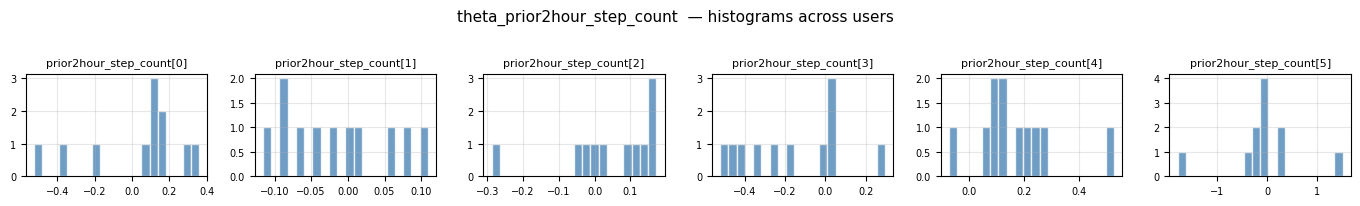

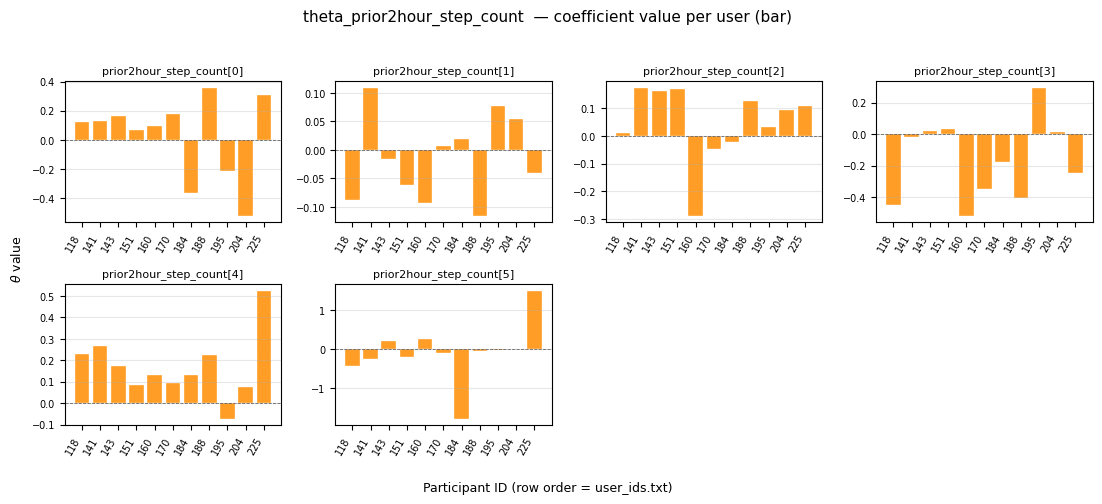

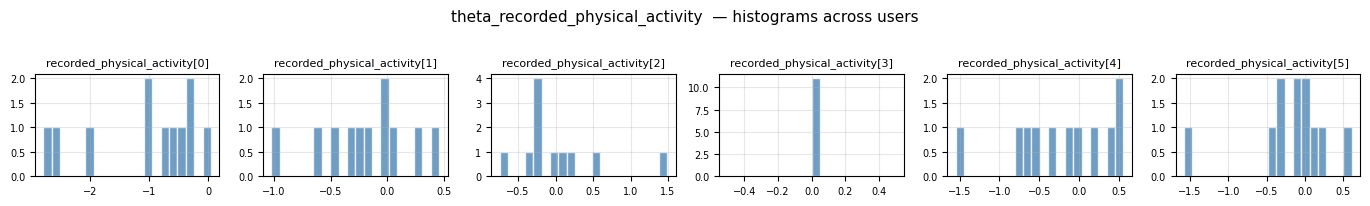

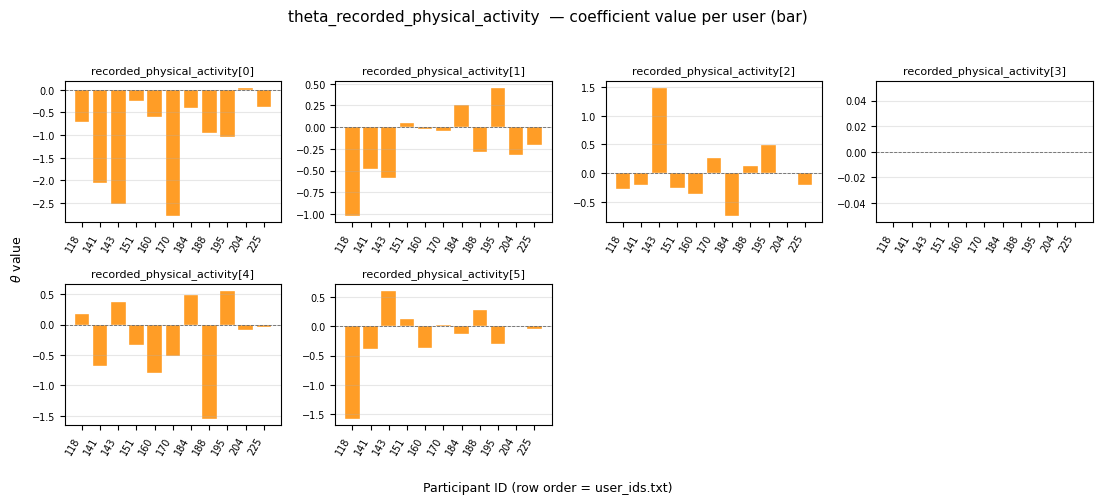

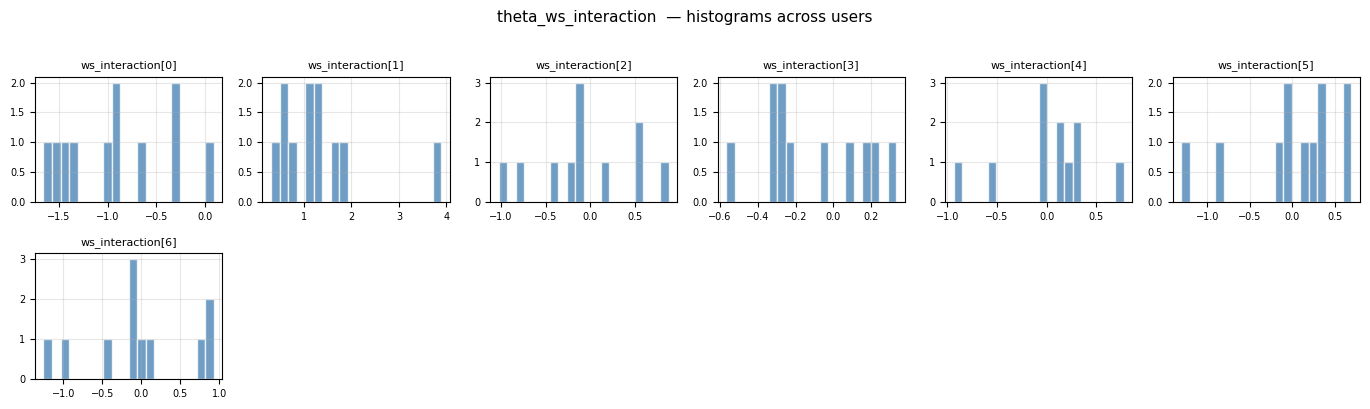

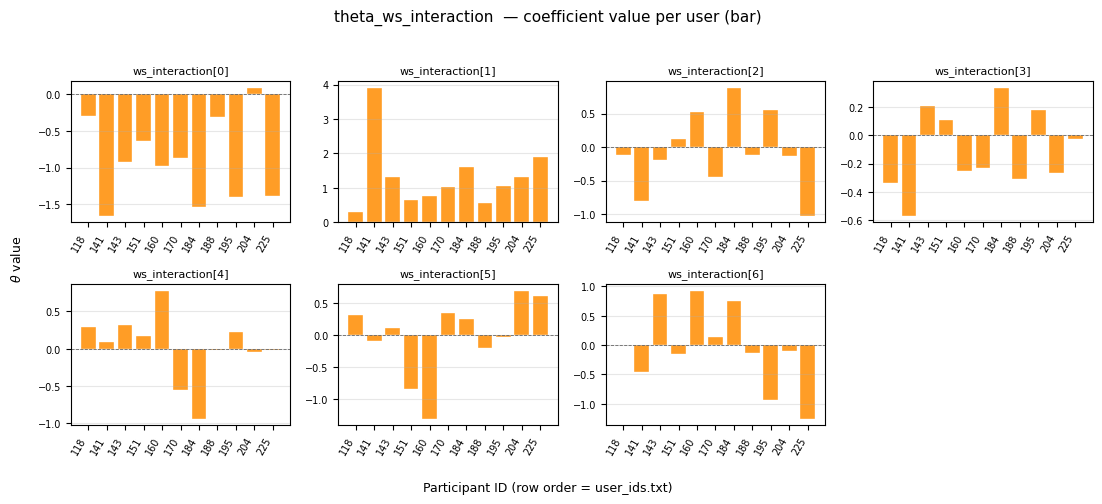

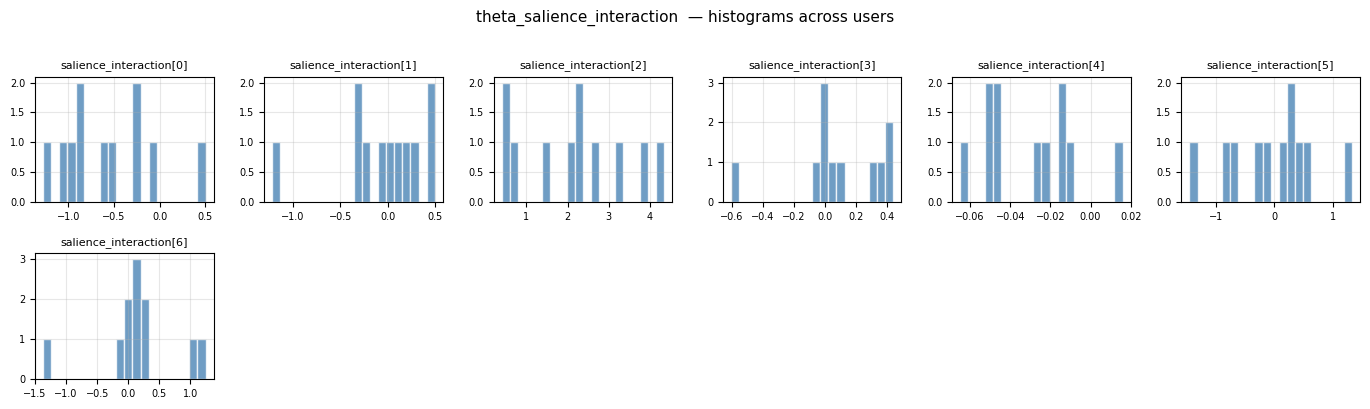

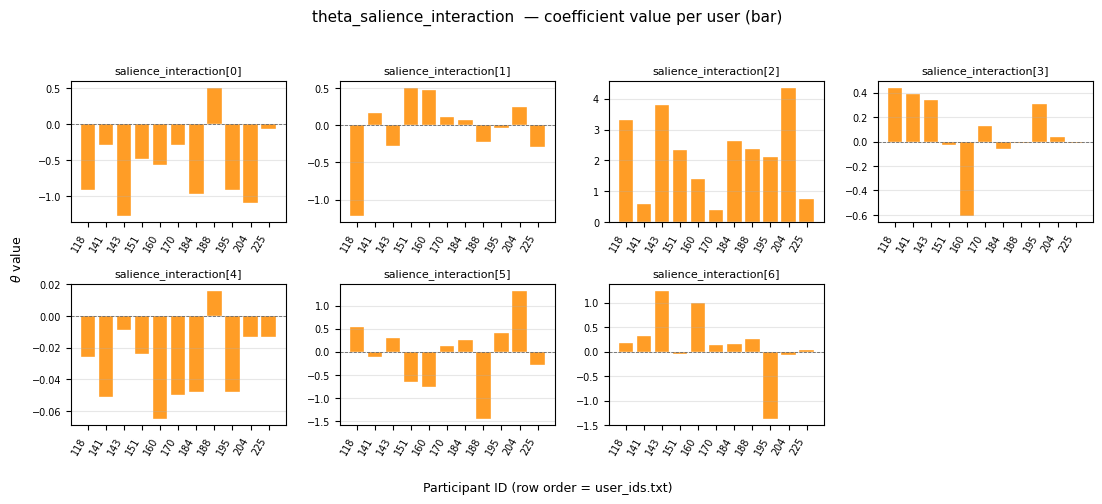

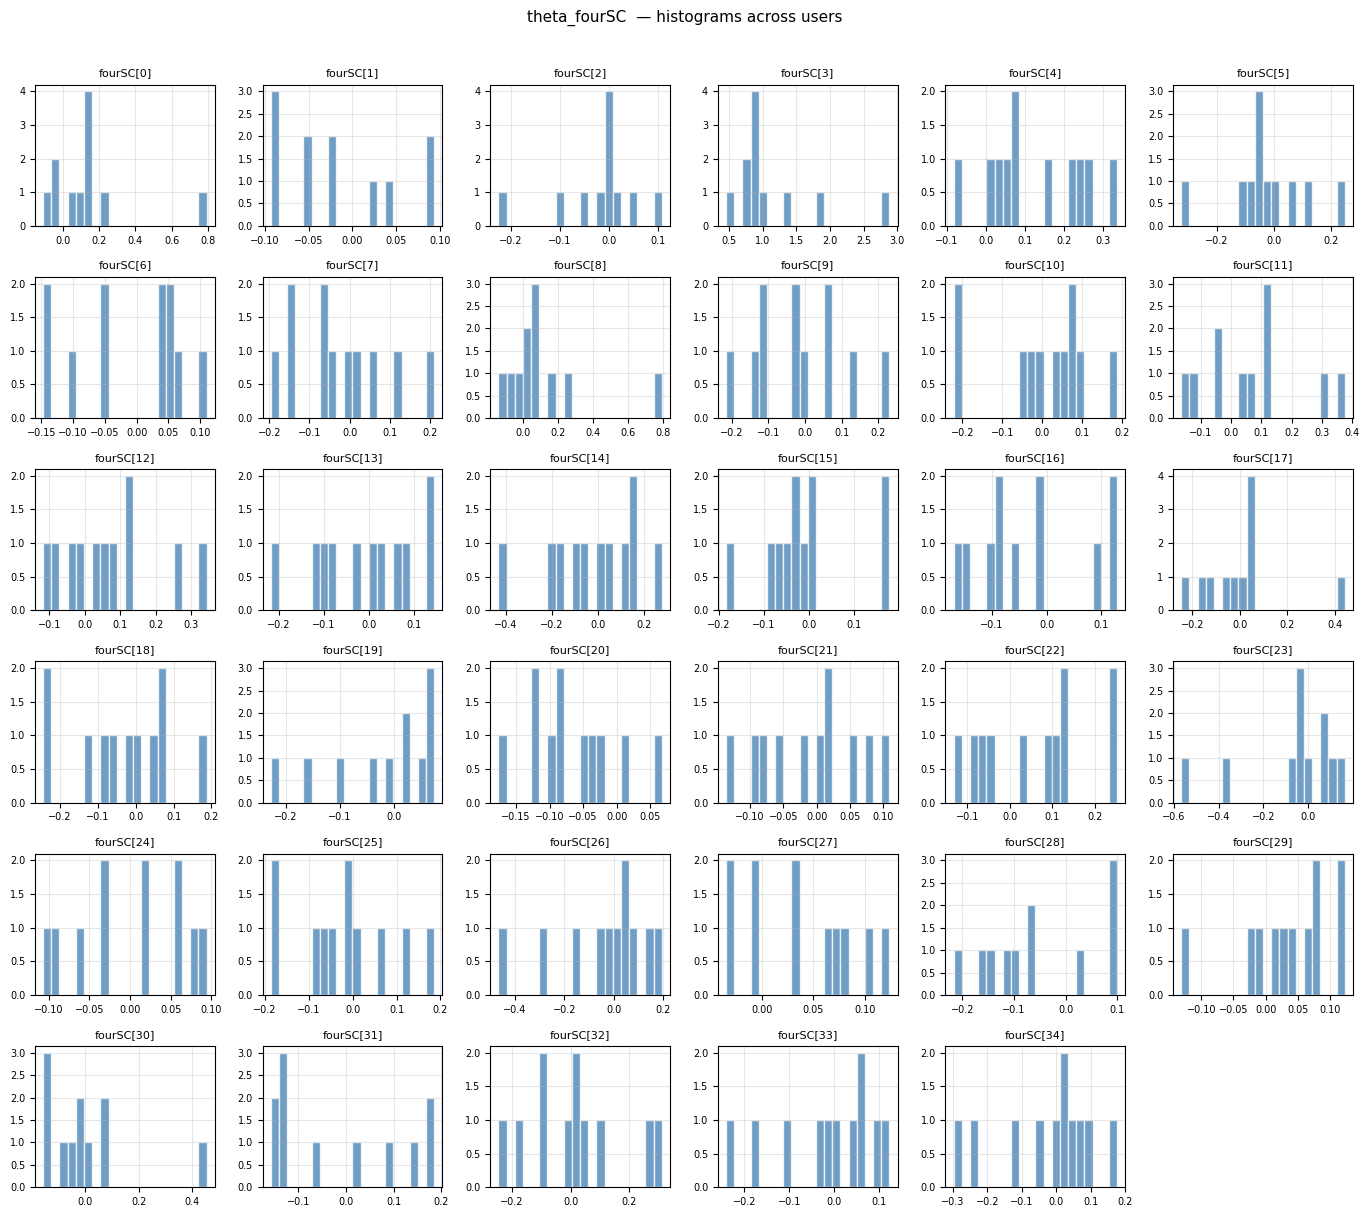

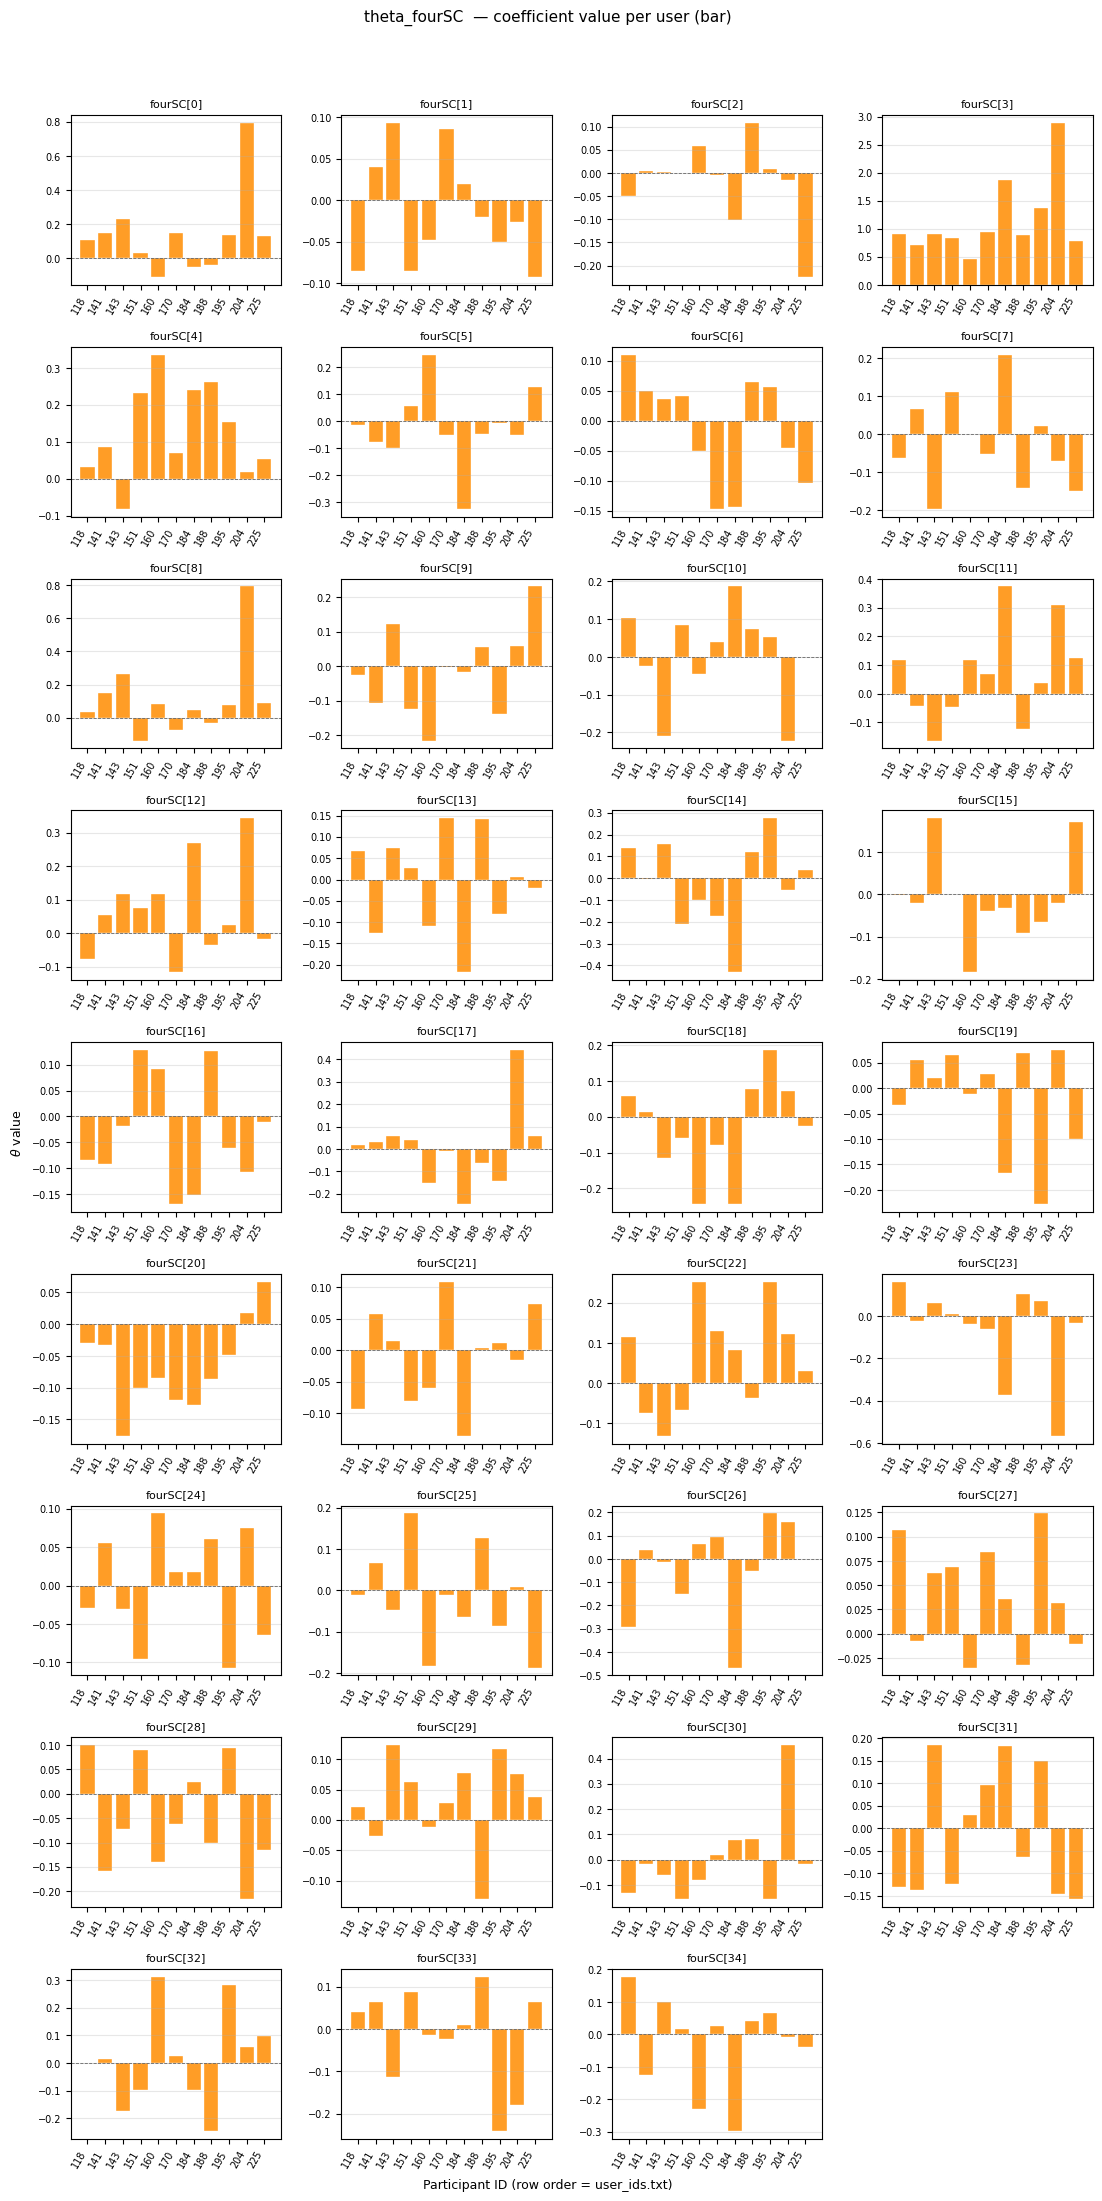

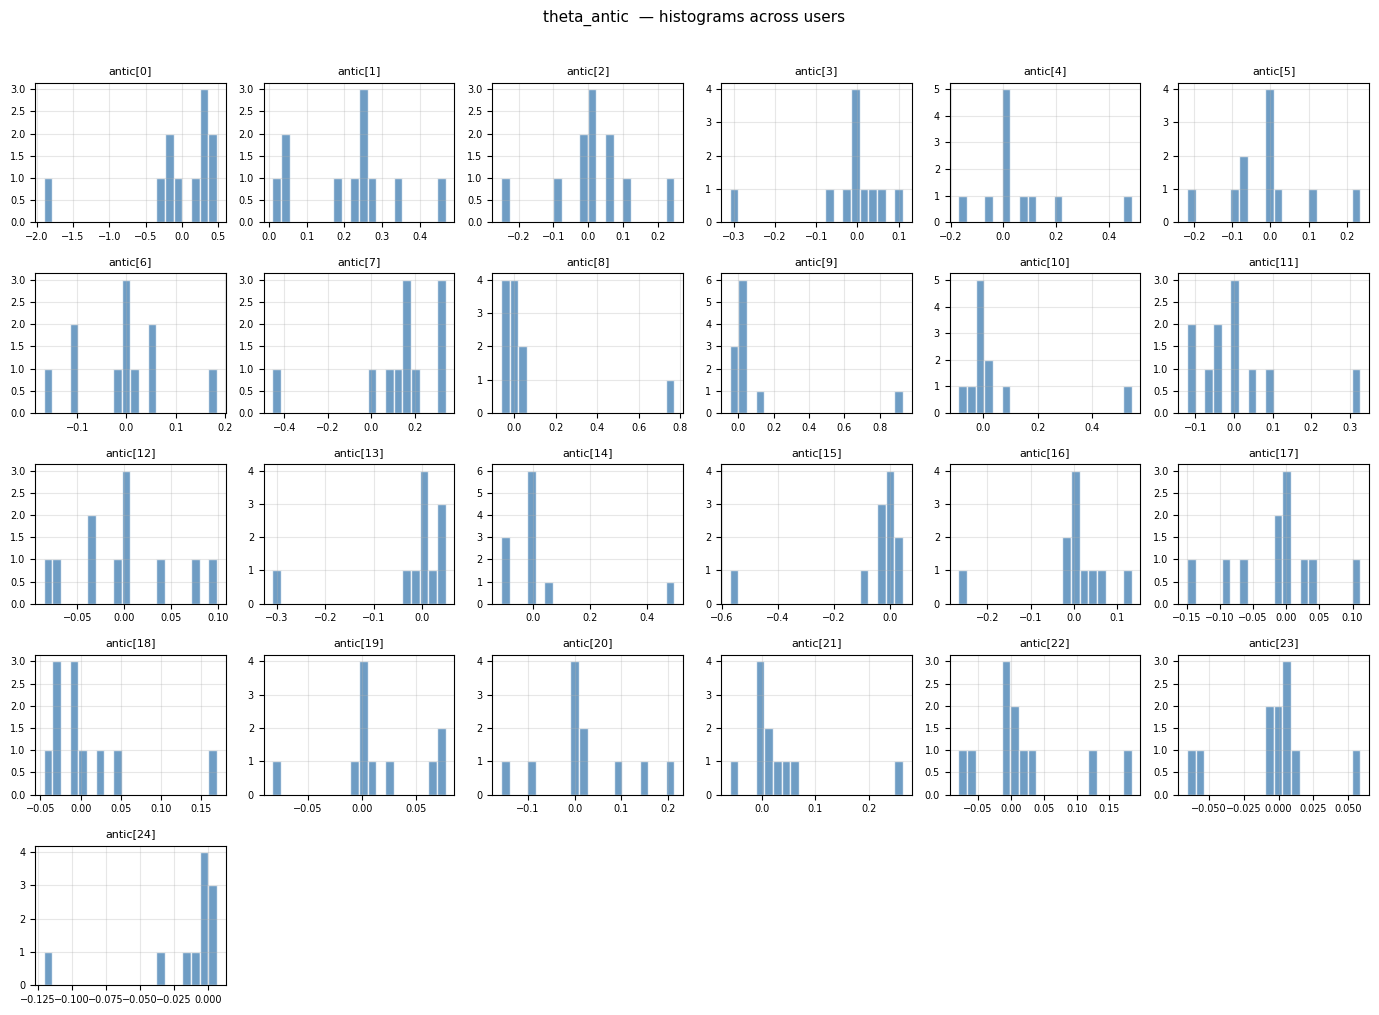

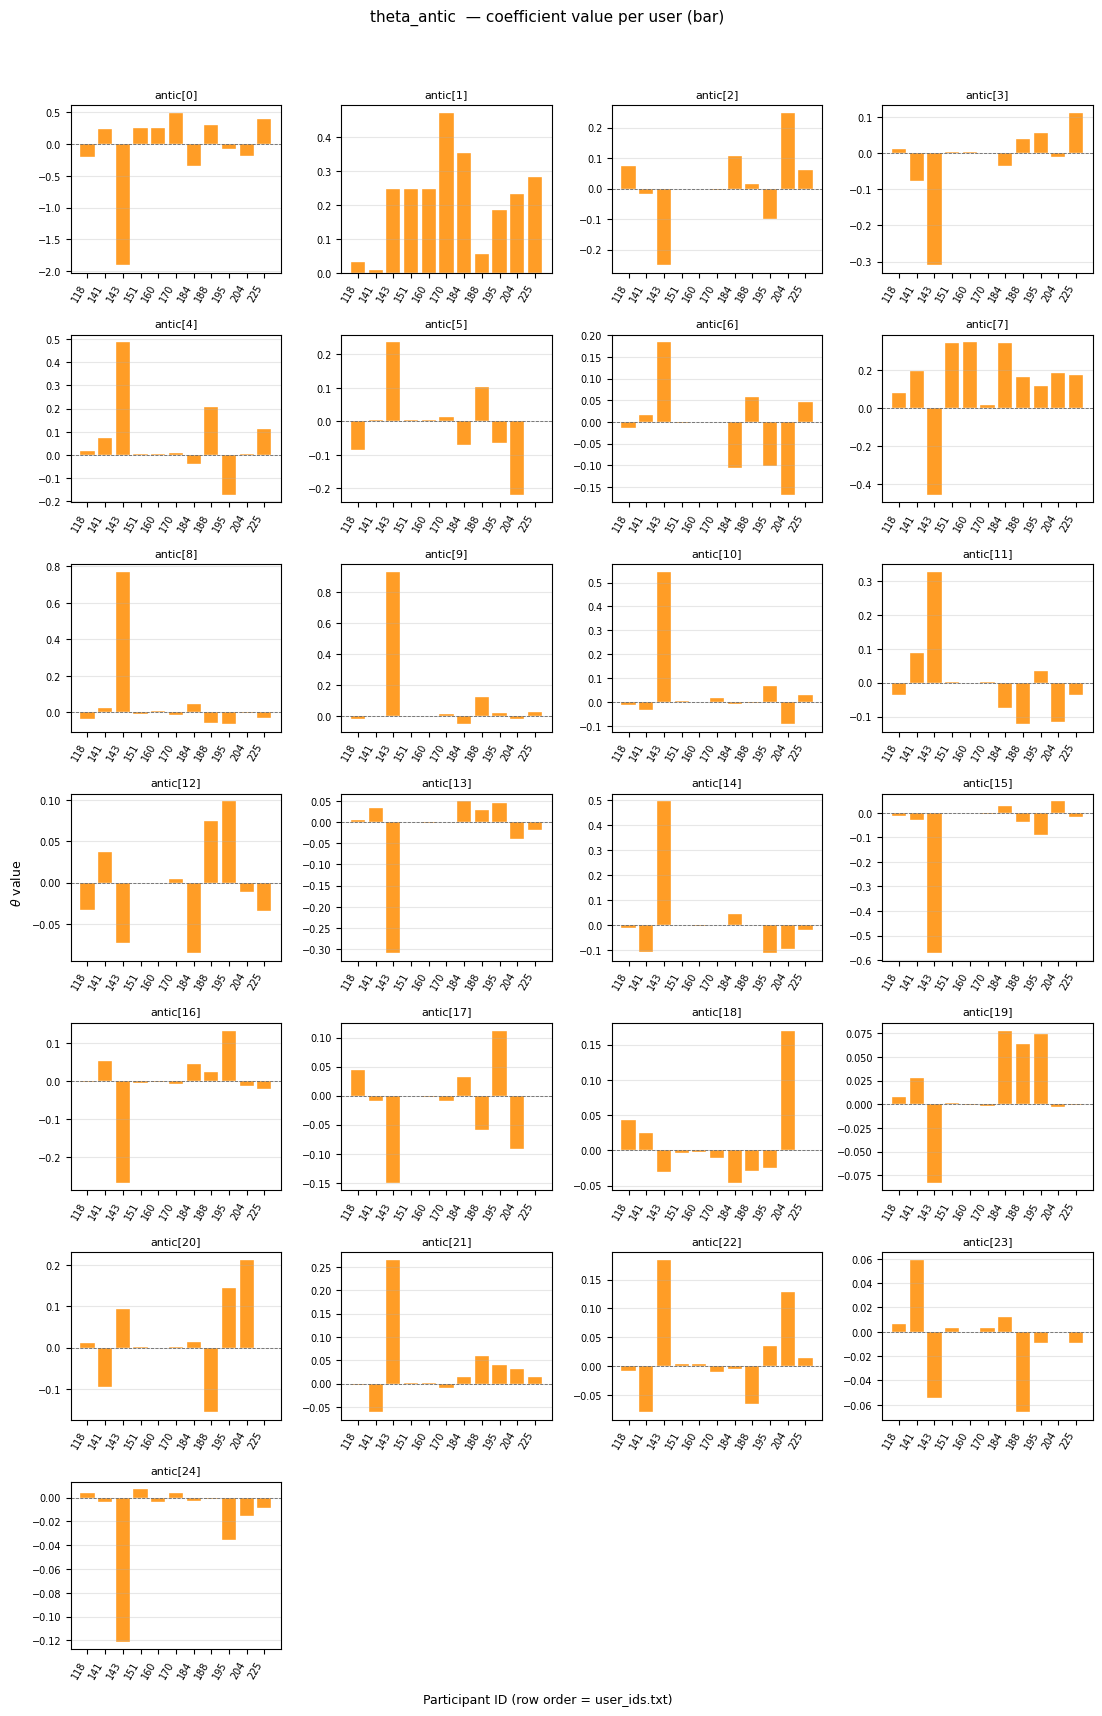

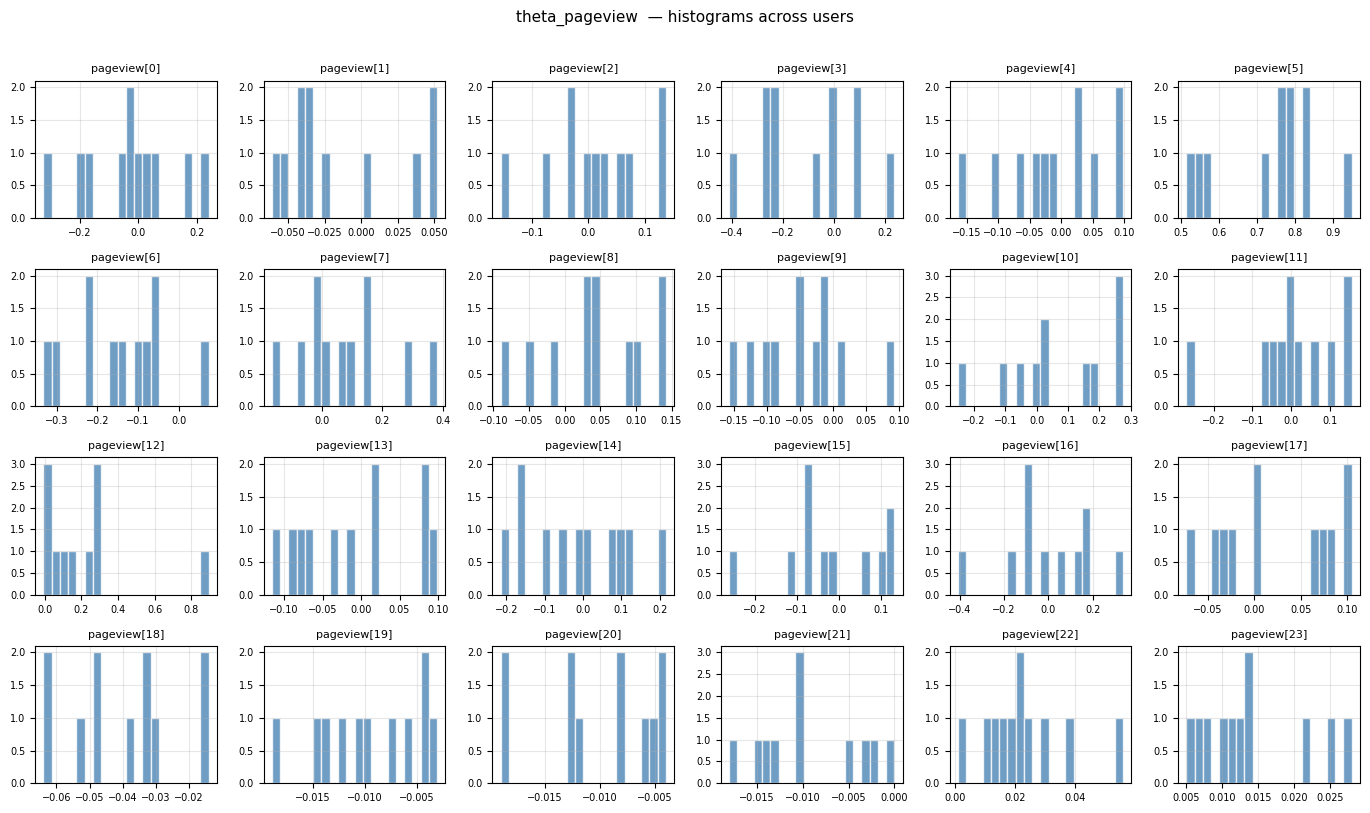

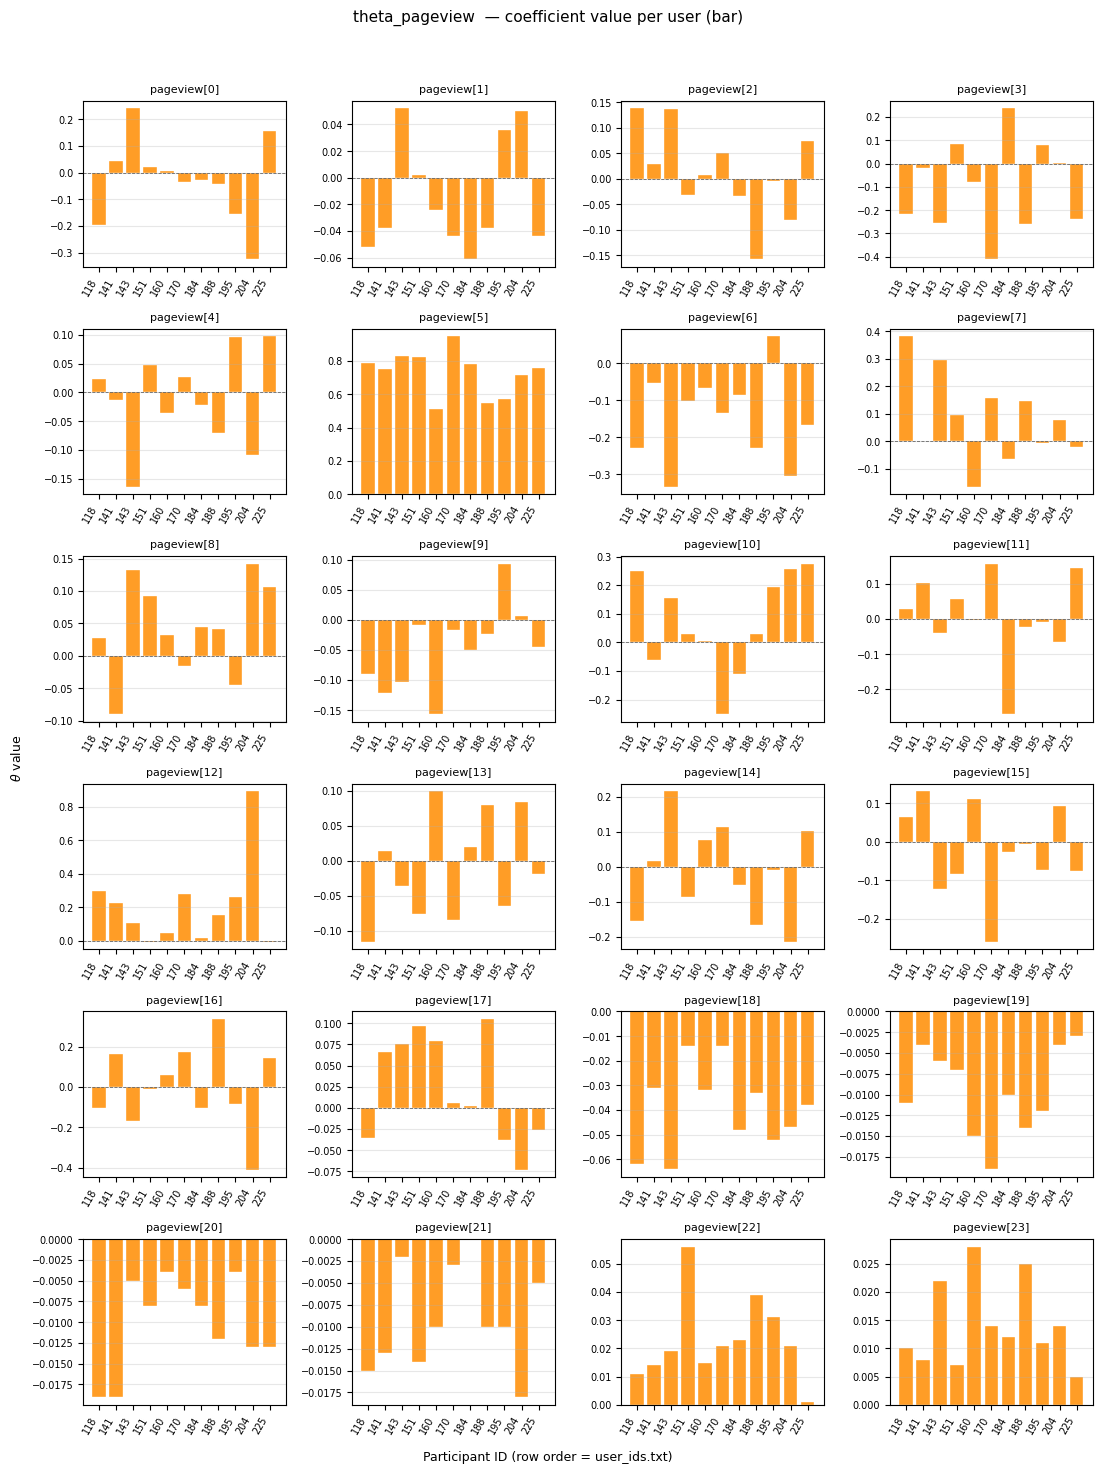

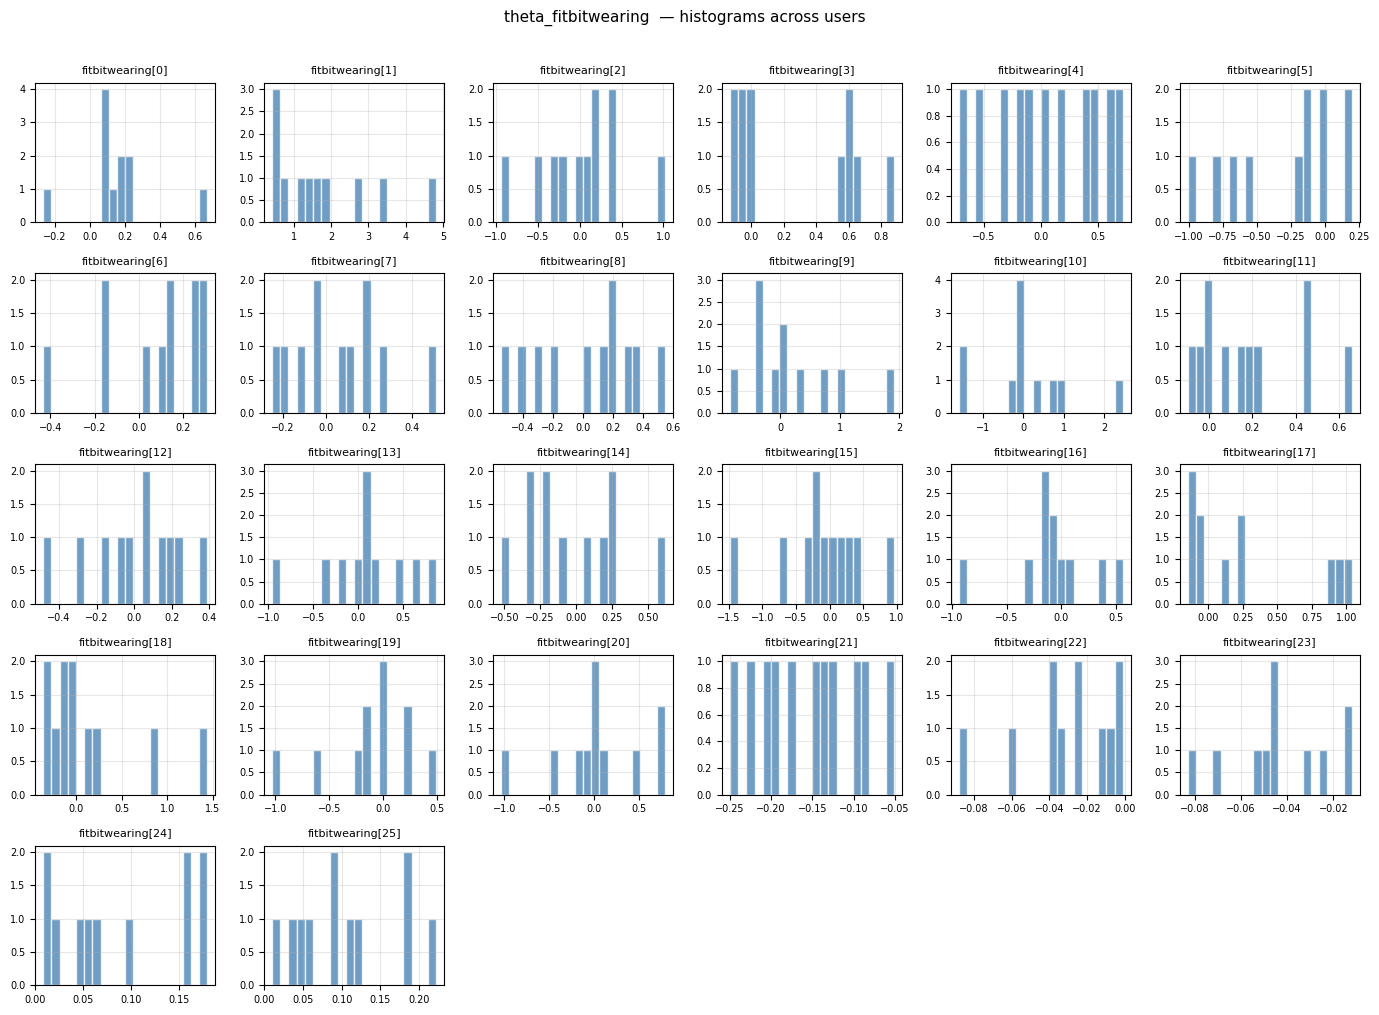

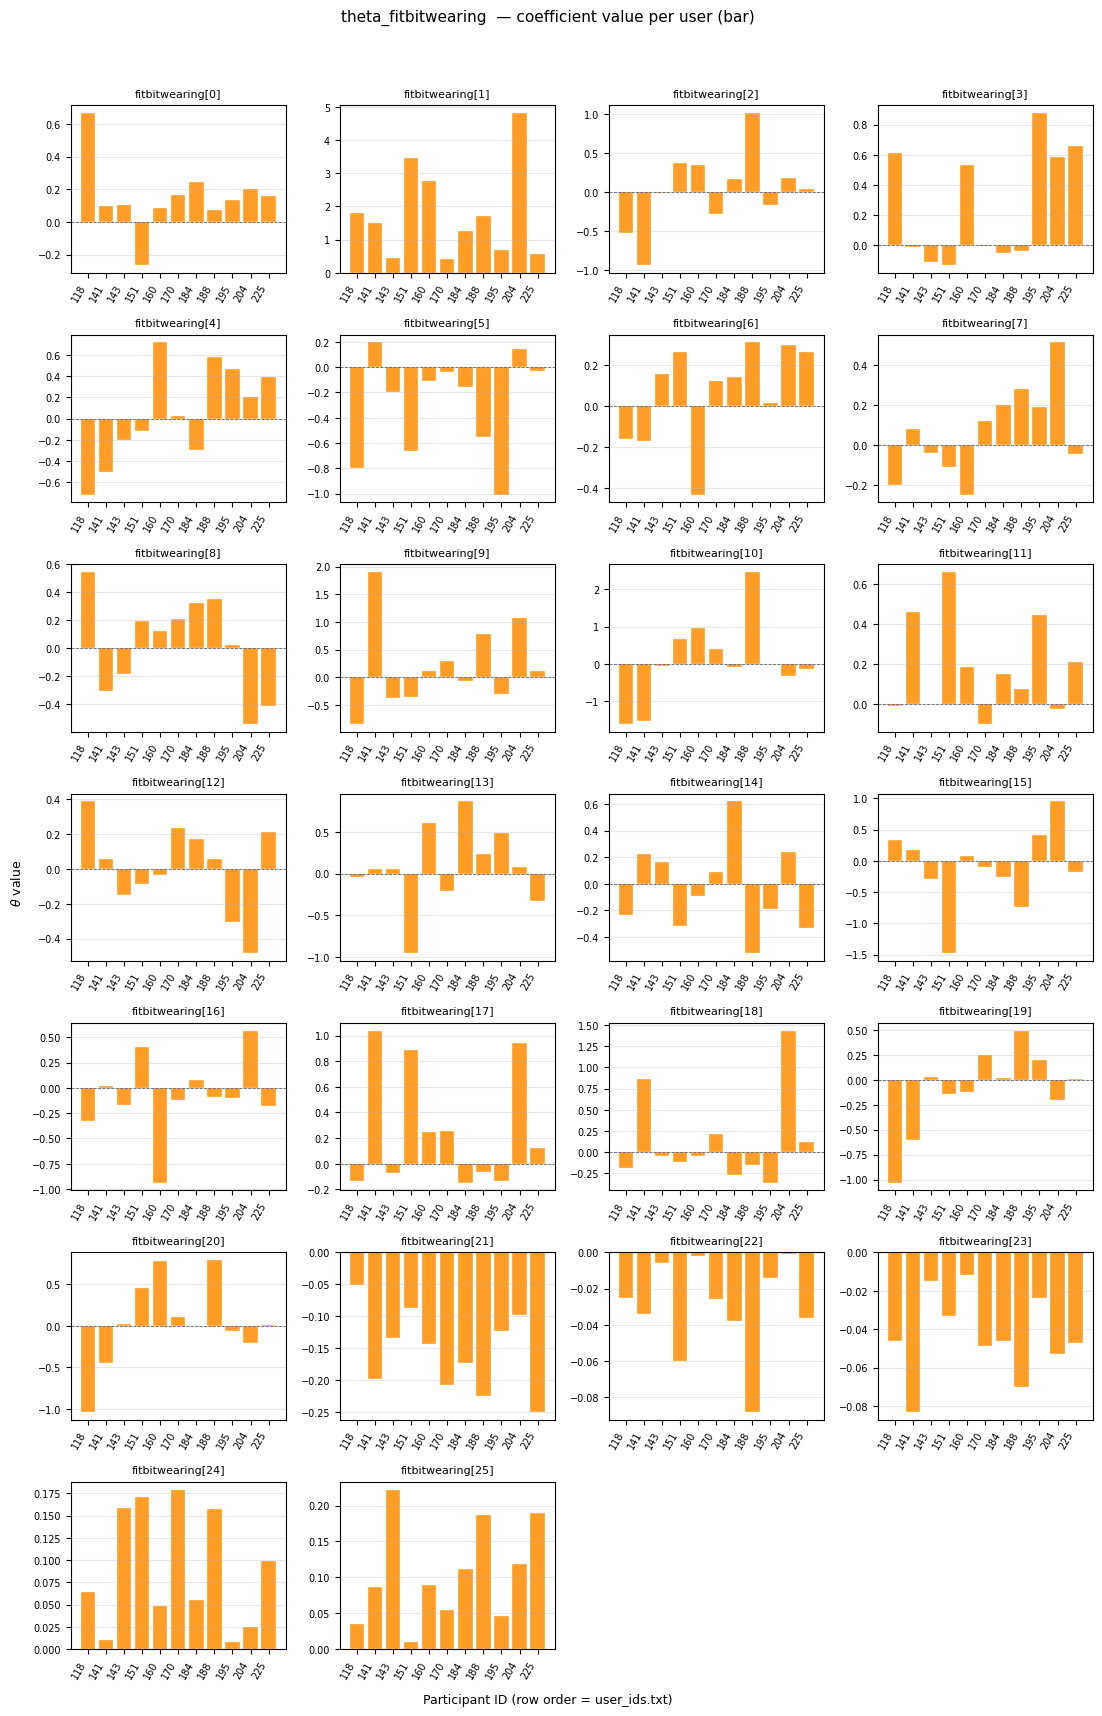

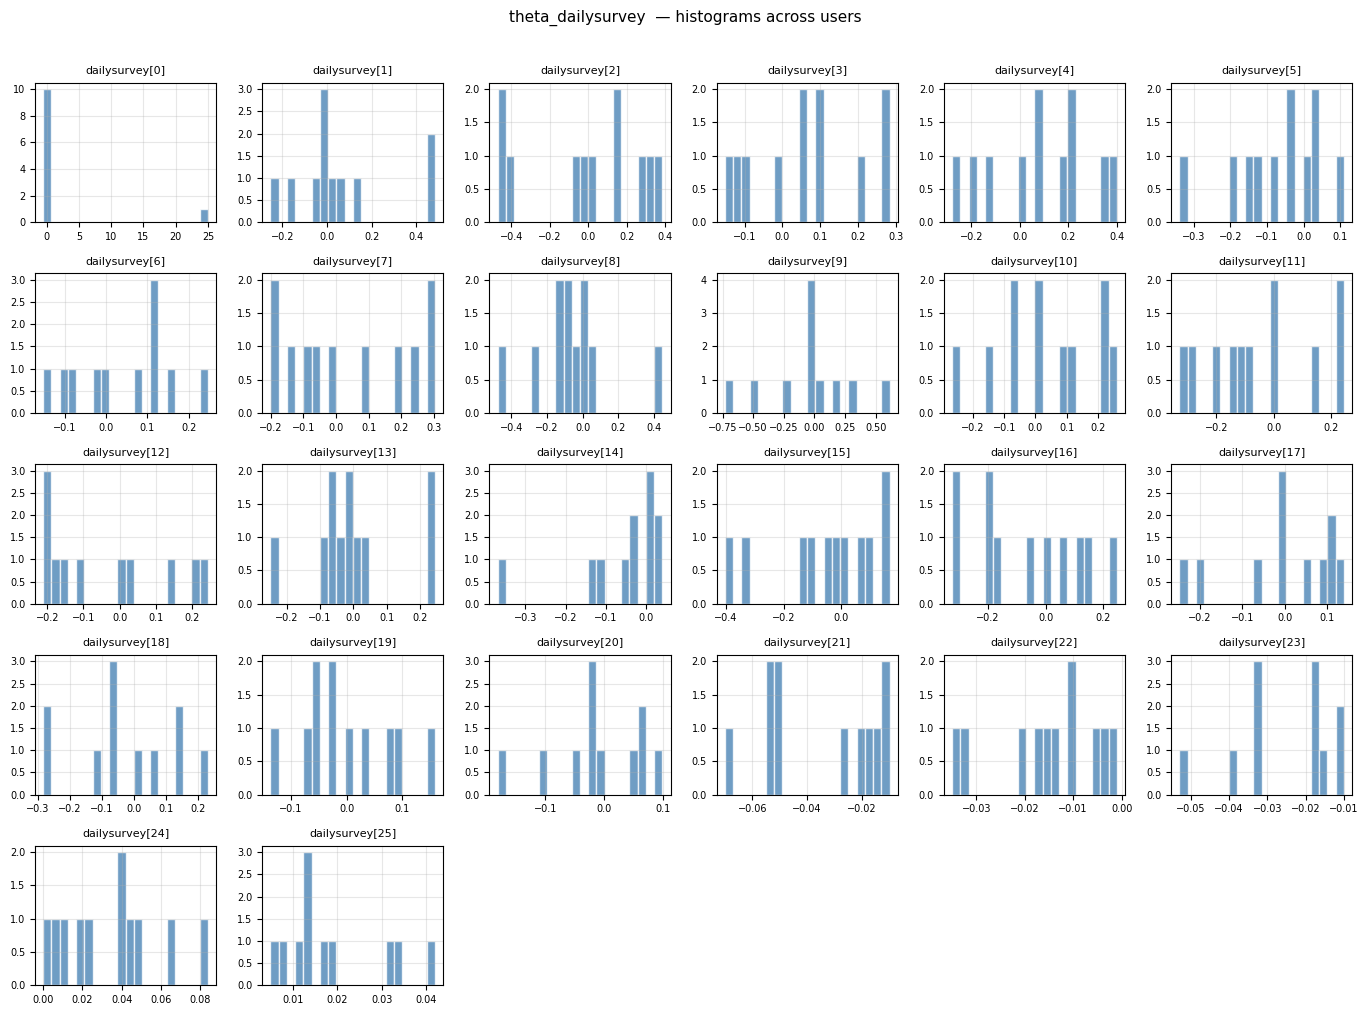

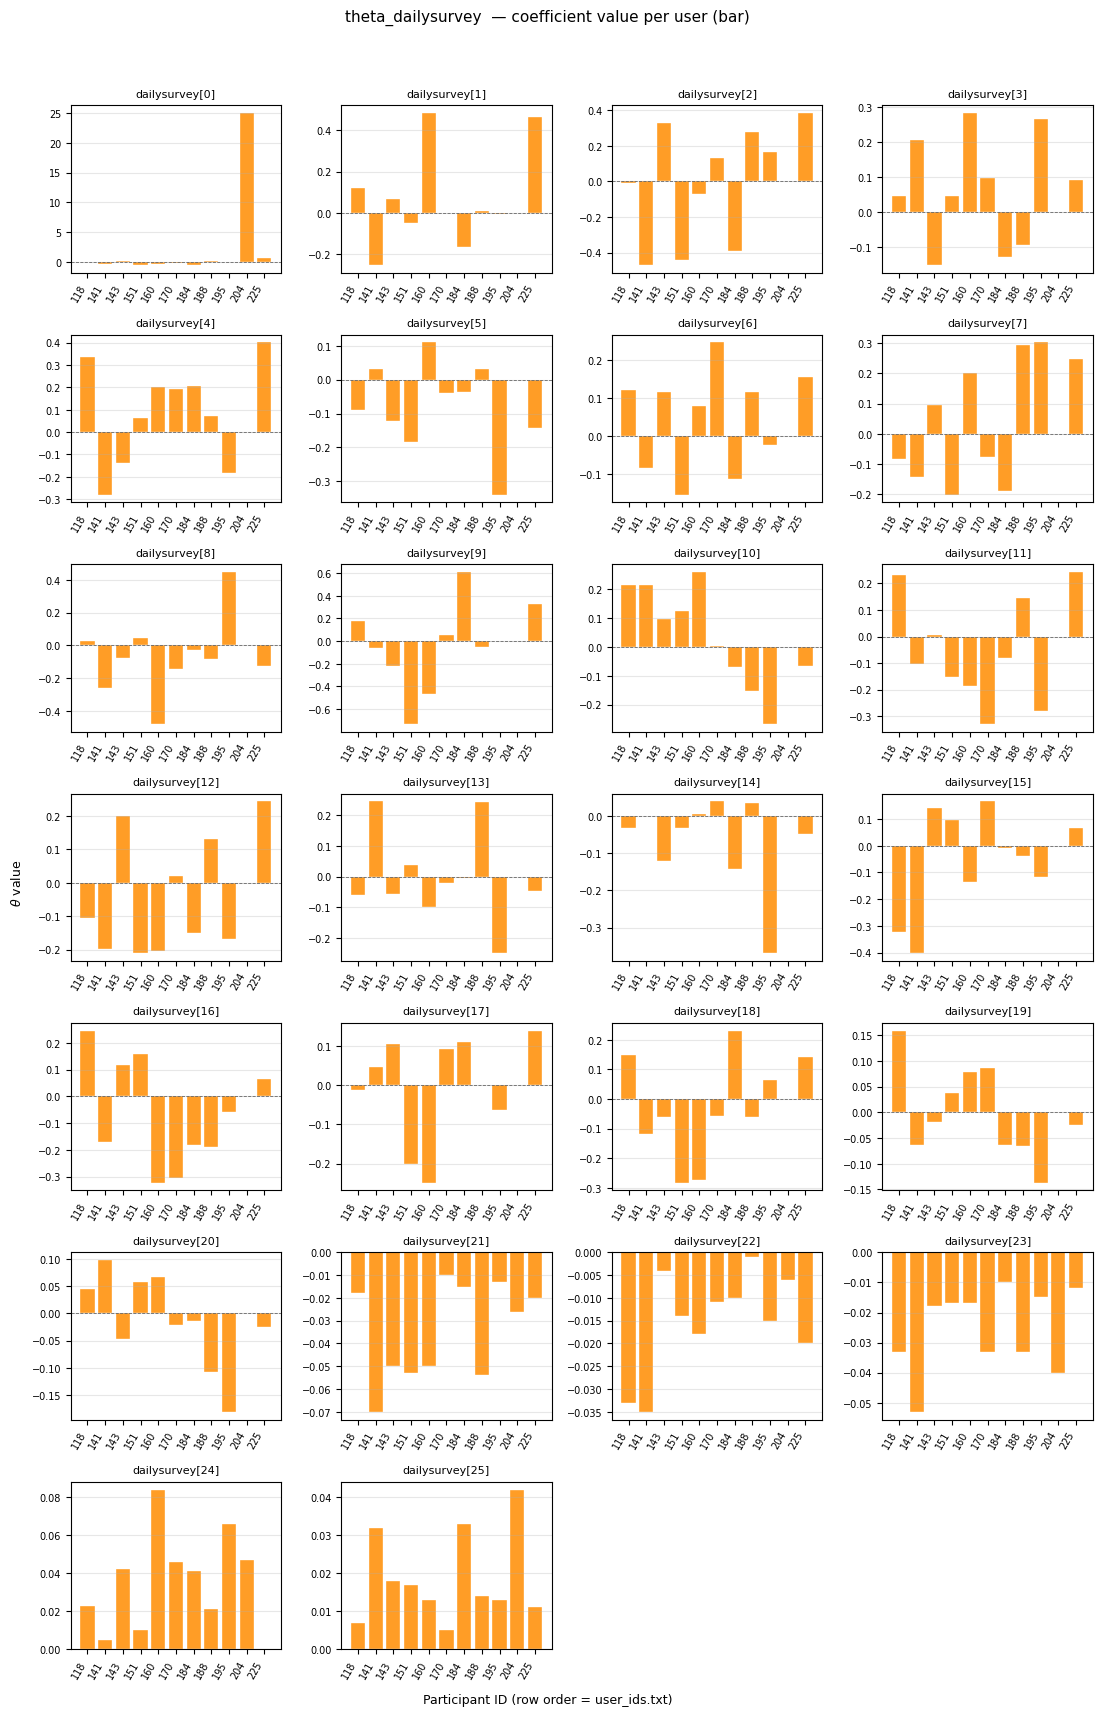

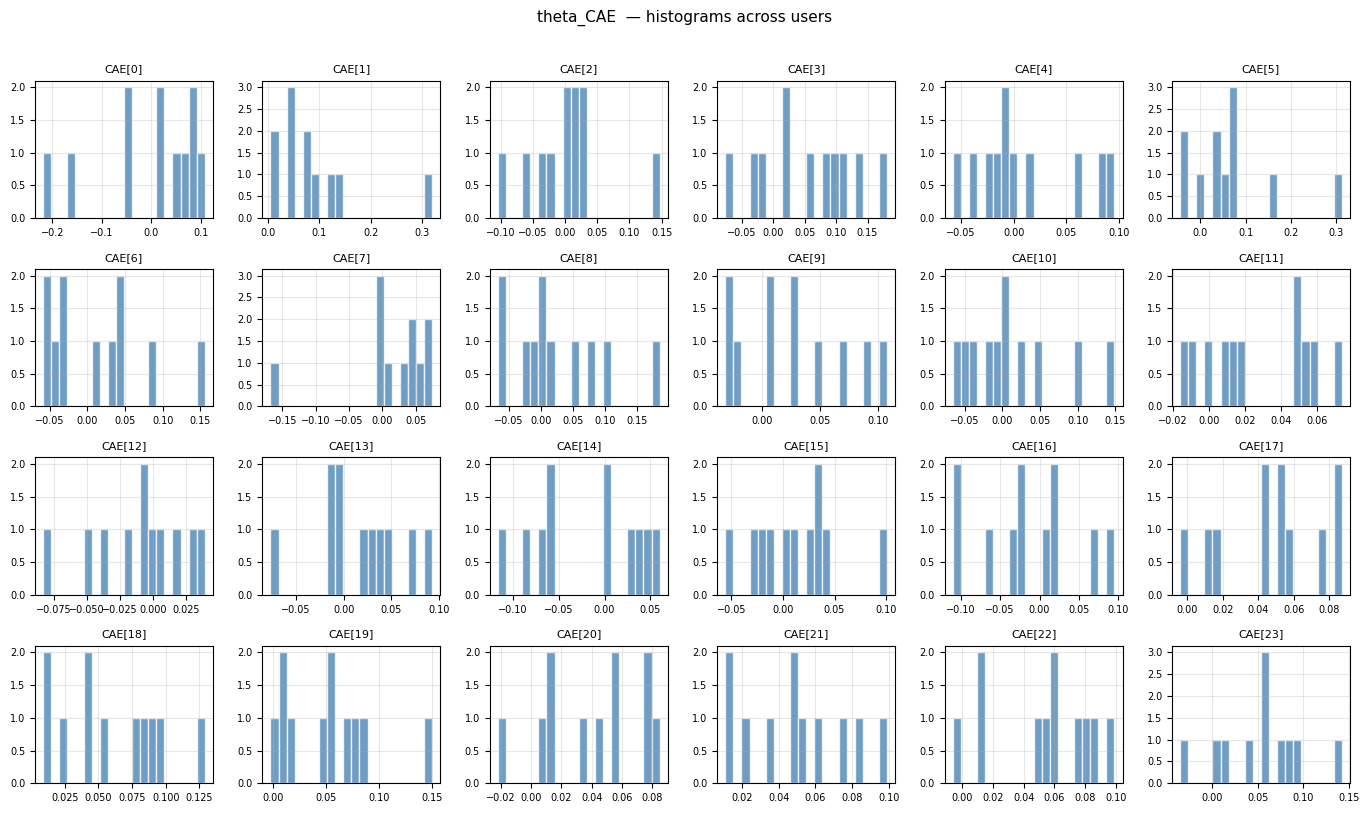

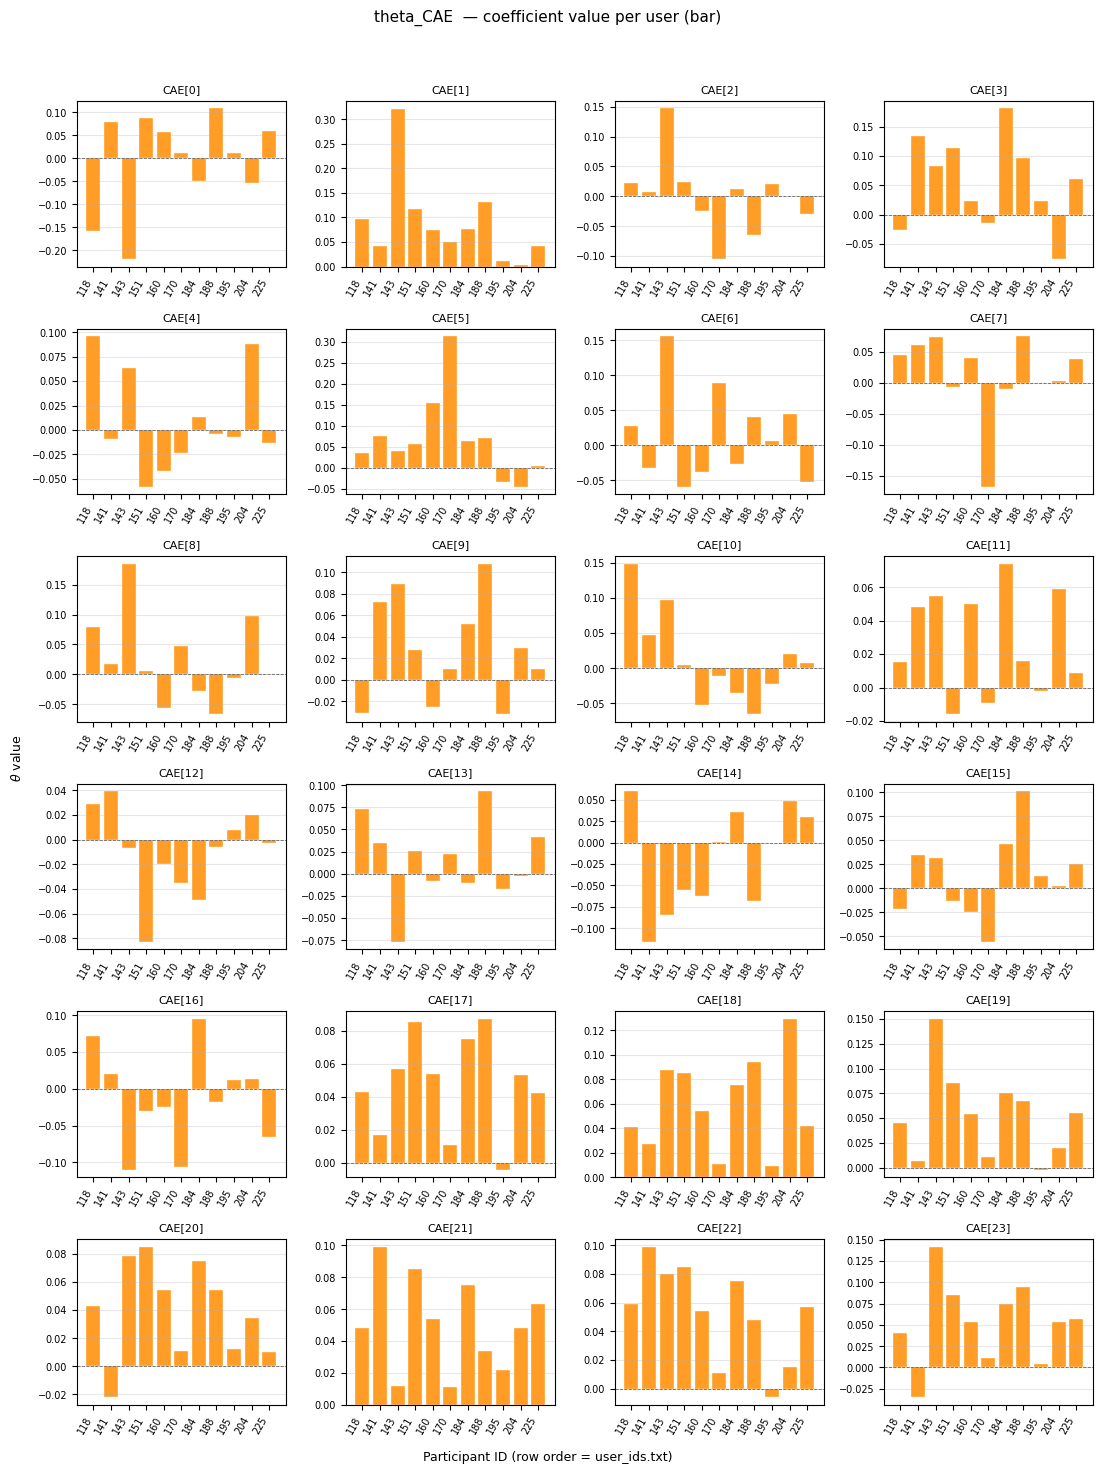

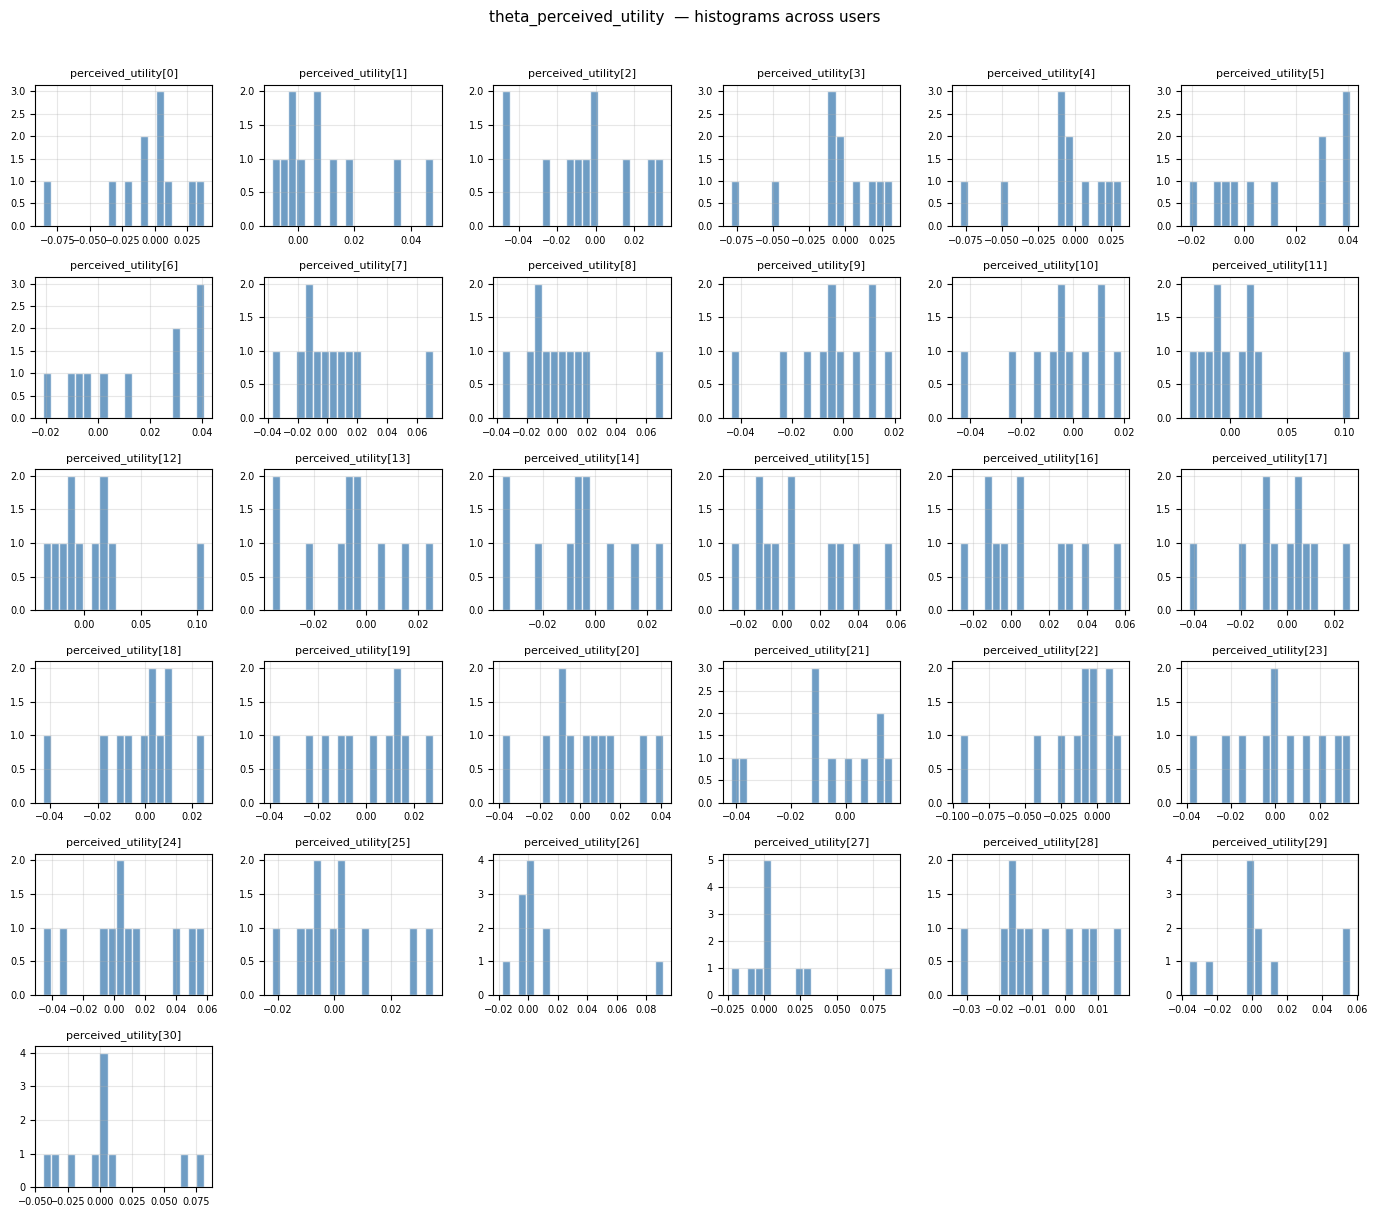

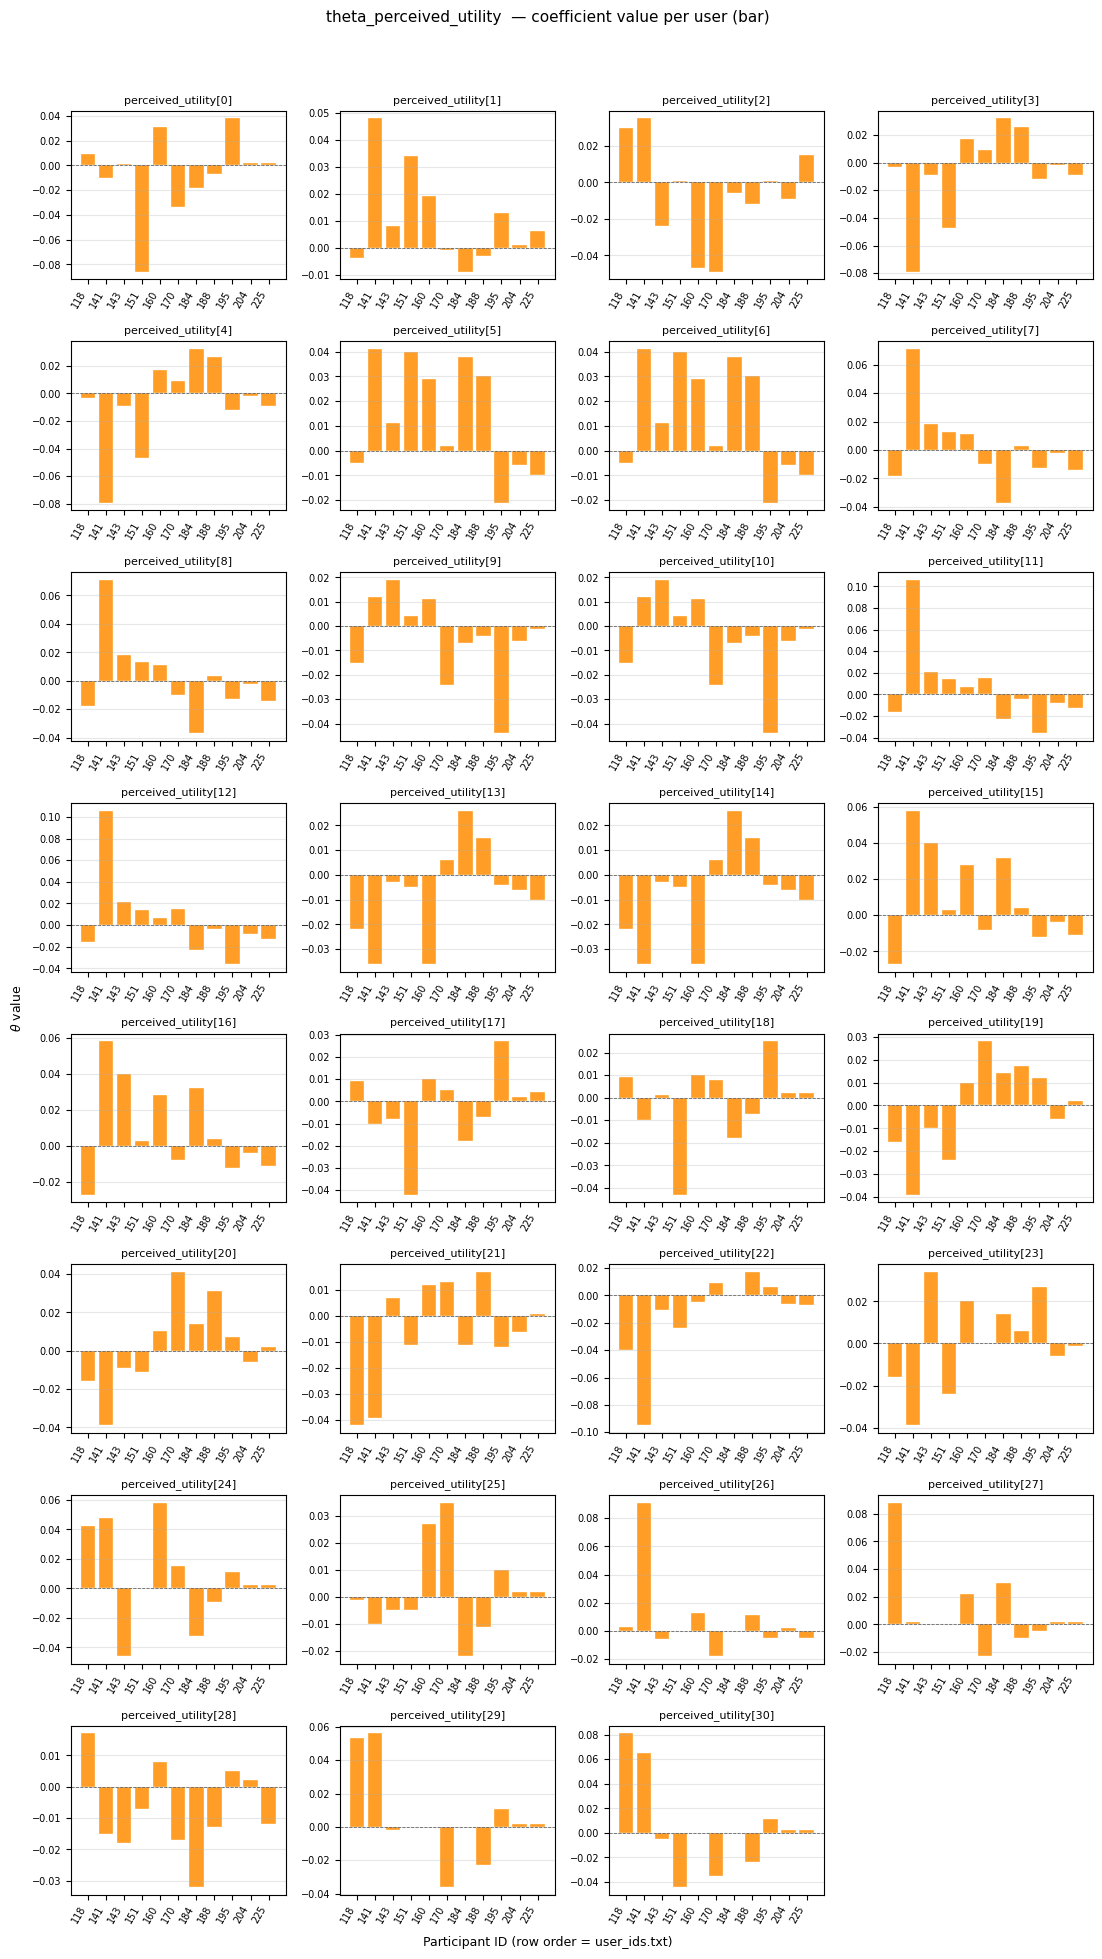

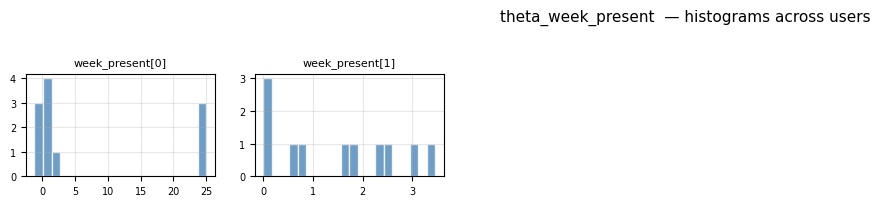

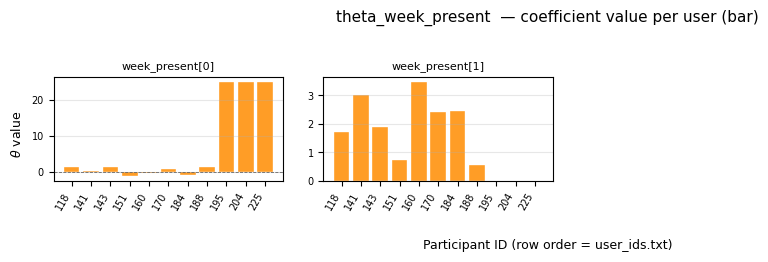

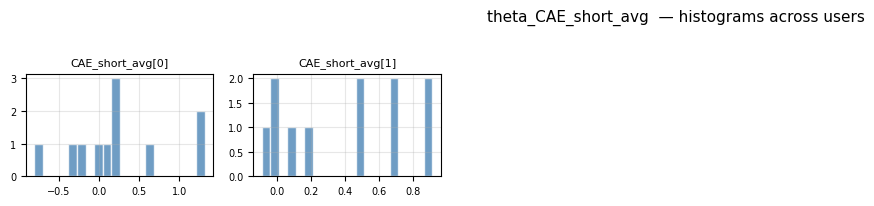

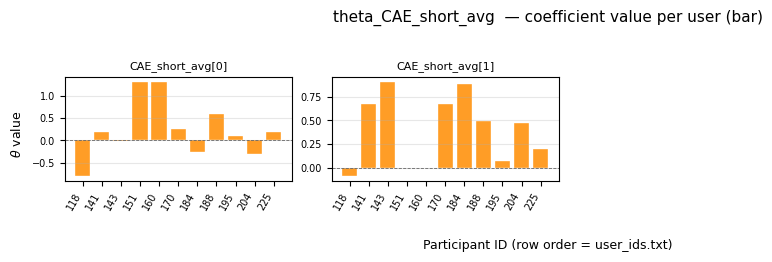

In [34]:
# Histograms + bar plots of every ``theta_*`` in ``params_env_{userid}.json`` (from ``2_fit_vanilla_testbed.py``)

THETA_KEYS = [
    "theta_prior2hour_step_count",
    "theta_recorded_physical_activity",
    "theta_ws_interaction",
    "theta_salience_interaction",
    "theta_fourSC",
    "theta_antic",
    "theta_pageview",
    "theta_fitbitwearing",
    "theta_dailysurvey",
    "theta_CAE",
    "theta_perceived_utility",
    "theta_week_present",
    "theta_CAE_short_avg",
]


def load_theta_matrix(param_key: str):
    """Shape ``(len(userid_all), n_coef)``; rows align with ``userid_all`` (missing → NaN)."""
    rows = []
    for uid in userid_all:
        pth = Path(file_params_env_prefix + str(int(uid)) + ".json")
        if not pth.is_file():
            rows.append(None)
            continue
        with open(pth, "r", encoding="utf-8") as f:
            p = json.load(f)
        if param_key not in p:
            rows.append(None)
            continue
        rows.append(np.asarray(p[param_key], dtype=float).ravel())
    if all(r is None for r in rows):
        return None
    maxlen = max((r.size for r in rows if r is not None), default=0)
    if maxlen == 0:
        return None
    mat = np.full((len(userid_all), maxlen), np.nan, dtype=float)
    for i, r in enumerate(rows):
        if r is not None:
            mat[i, : r.size] = r
    return mat


def plot_theta_histograms(param_key: str, M: np.ndarray, *, max_cols: int = 6, n_bins: int = 20):
    if M is None or M.size == 0:
        print(f"(skip {param_key}: no data)")
        return
    n_coef = M.shape[1]
    n_rows = int(math.ceil(n_coef / max_cols))
    fig, axes = plt.subplots(
        n_rows,
        max_cols,
        figsize=(2.3 * max_cols, 2.0 * n_rows),
        squeeze=False,
    )
    axes = np.asarray(axes).reshape(-1)
    short = param_key.replace("theta_", "")
    for j in range(n_coef):
        ax = axes[j]
        x = M[:, j]
        x = x[np.isfinite(x)]
        if x.size == 0:
            ax.set_visible(False)
            continue
        ax.hist(x, bins=n_bins, alpha=0.78, color="steelblue", edgecolor="white")
        ax.set_title(f"{short}[{j}]", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
    for k in range(n_coef, axes.size):
        axes[k].set_visible(False)
    fig.suptitle(param_key + "  — histograms across users", fontsize=11, y=1.01)
    fig.tight_layout()
    plt.show()


def plot_theta_bars(param_key: str, M: np.ndarray, *, max_cols: int = 4):
    """For each coefficient index: one bar per user (x = participant id)."""
    if M is None or M.size == 0:
        print(f"(skip bar {param_key}: no data)")
        return
    n_coef = M.shape[1]
    n_rows = int(math.ceil(n_coef / max_cols))
    fig, axes = plt.subplots(
        n_rows,
        max_cols,
        figsize=(2.8 * max_cols, 2.4 * n_rows),
        squeeze=False,
    )
    axes = np.asarray(axes).reshape(-1)
    short = param_key.replace("theta_", "")
    x = np.arange(len(userid_all))
    labels = [str(int(u)) for u in userid_all]
    for j in range(n_coef):
        ax = axes[j]
        y = M[:, j]
        if not np.any(np.isfinite(y)):
            ax.set_visible(False)
            continue
        ax.bar(x, y, color="darkorange", alpha=0.85, edgecolor="white", linewidth=0.3)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
        ax.set_title(f"{short}[{j}]", fontsize=8)
        ax.tick_params(axis="y", labelsize=7)
        ax.grid(True, axis="y", alpha=0.3)
        ax.axhline(0.0, color="0.4", linewidth=0.6, linestyle="--")
    for k in range(n_coef, axes.size):
        axes[k].set_visible(False)
    fig.suptitle(param_key + "  — coefficient value per user (bar)", fontsize=11, y=1.02)
    fig.supxlabel("Participant ID (row order = user_ids.txt)", fontsize=9)
    fig.supylabel(r"$\theta$ value", fontsize=9)
    fig.tight_layout()
    plt.show()


for _key in THETA_KEYS:
    _M = load_theta_matrix(_key)
    plot_theta_histograms(_key, _M)
    plot_theta_bars(_key, _M)


/var/folders/hz/q4hdsnpj1h50x_jpx8v5mrvc0000gn/T/ipykernel_91742/88978792.py:57: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


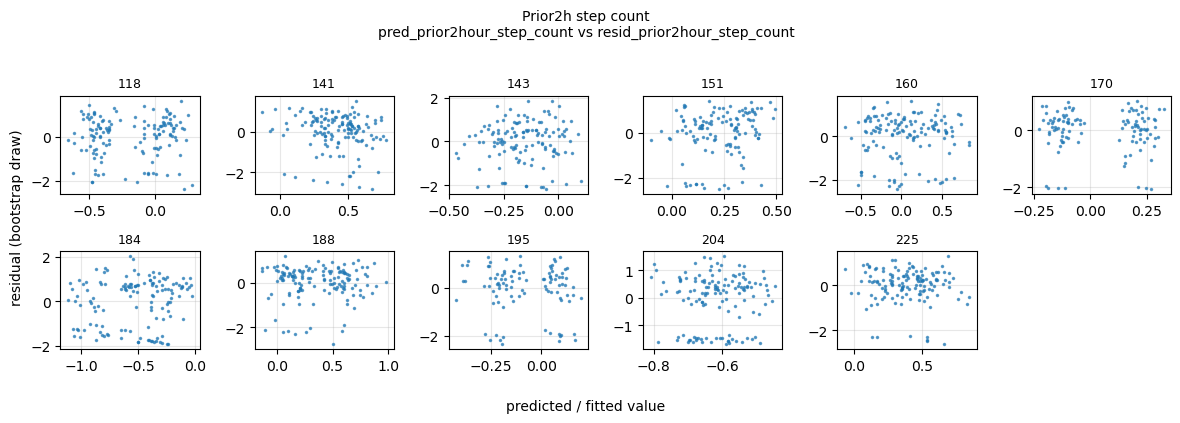

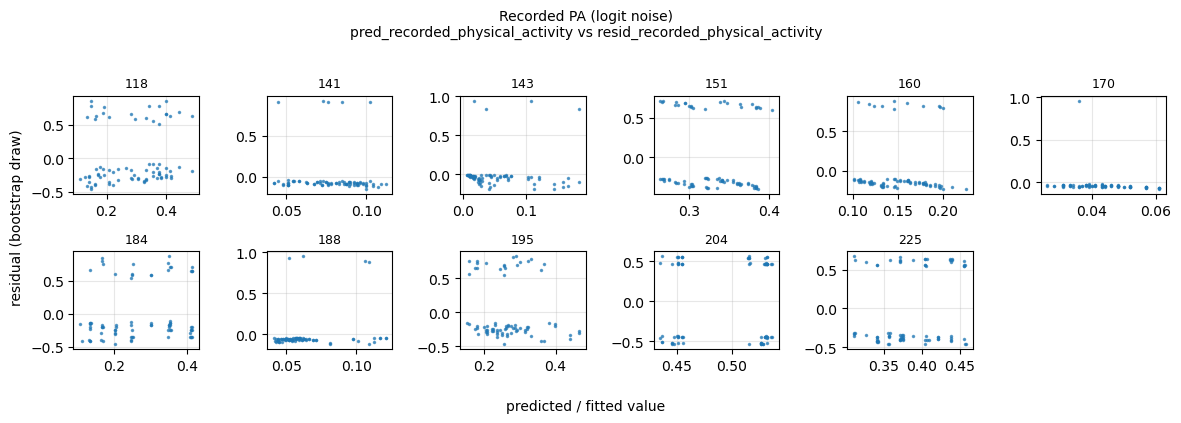

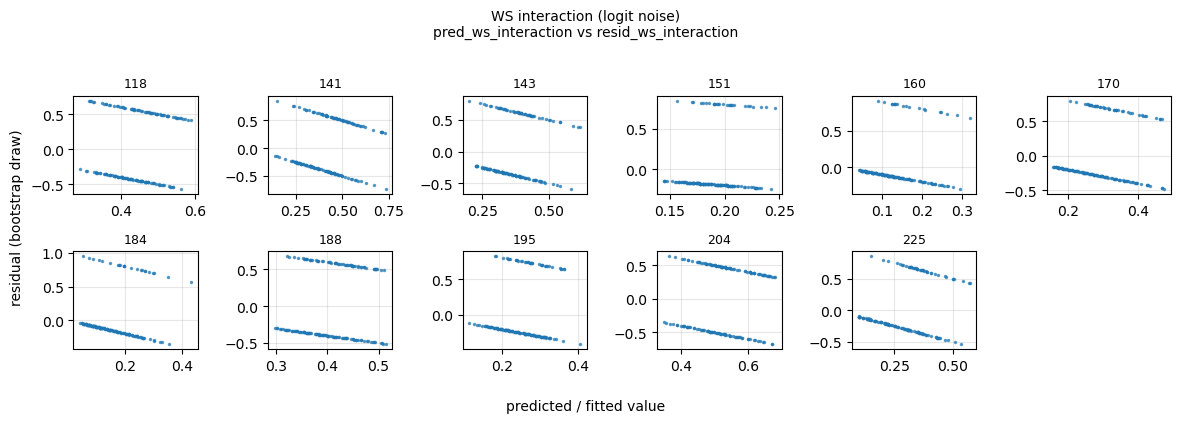

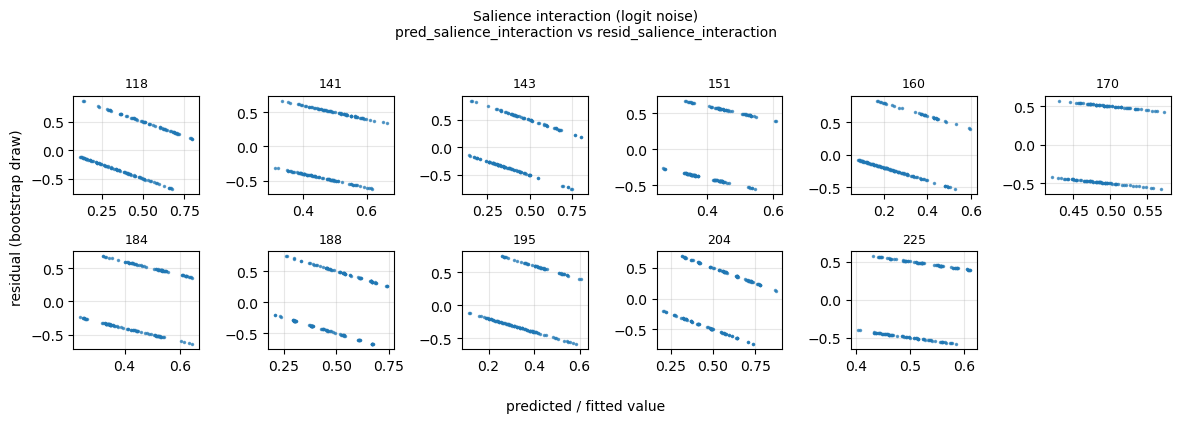

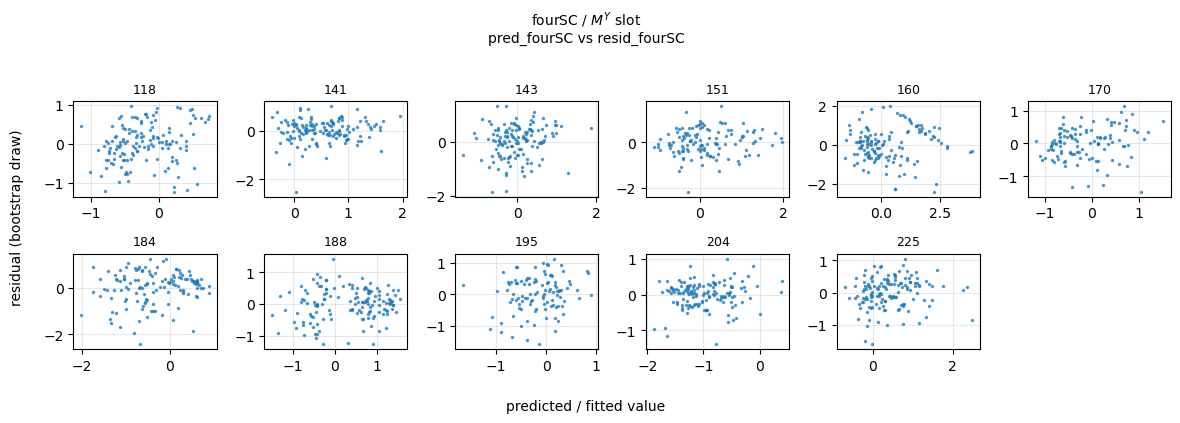

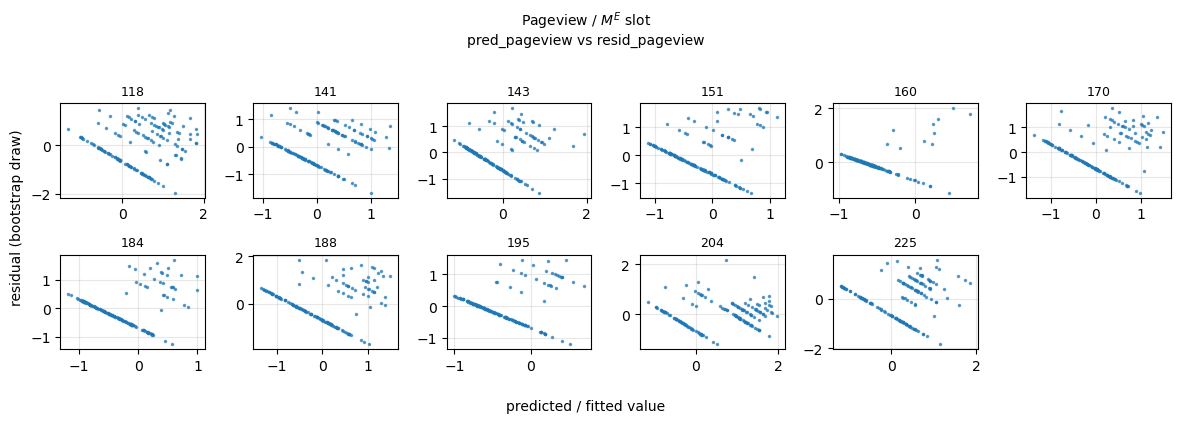

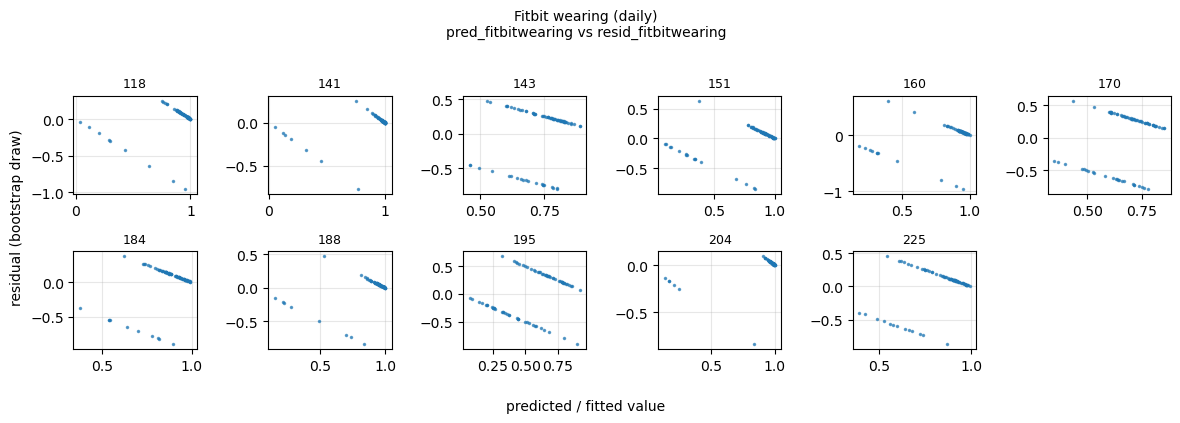

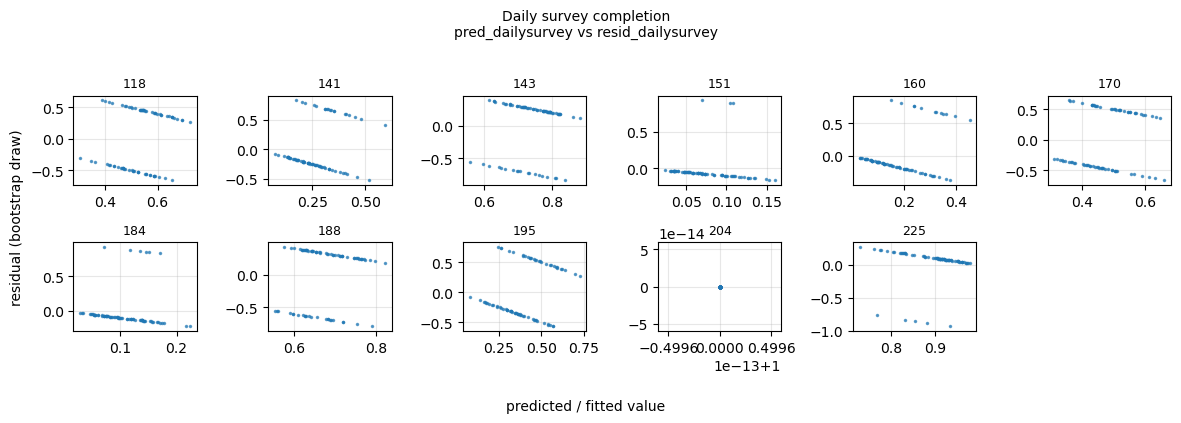

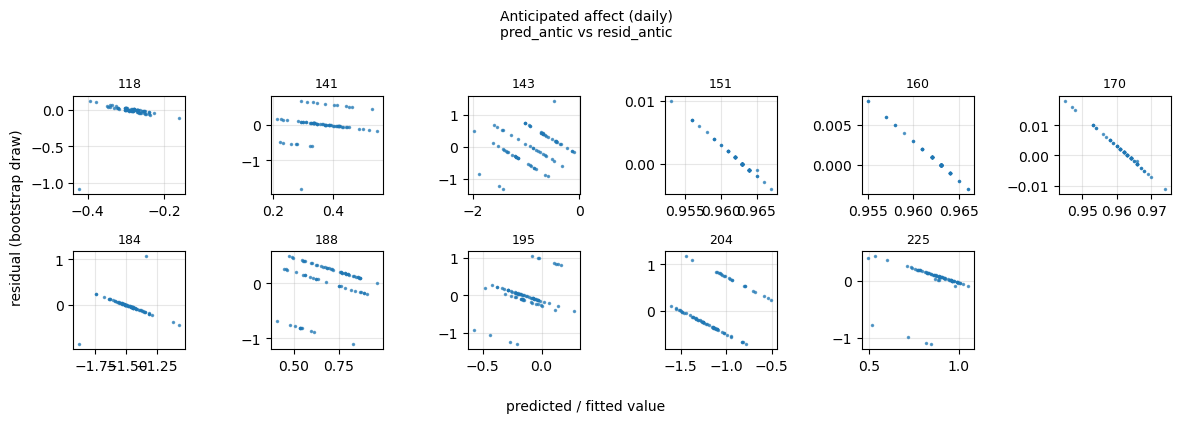

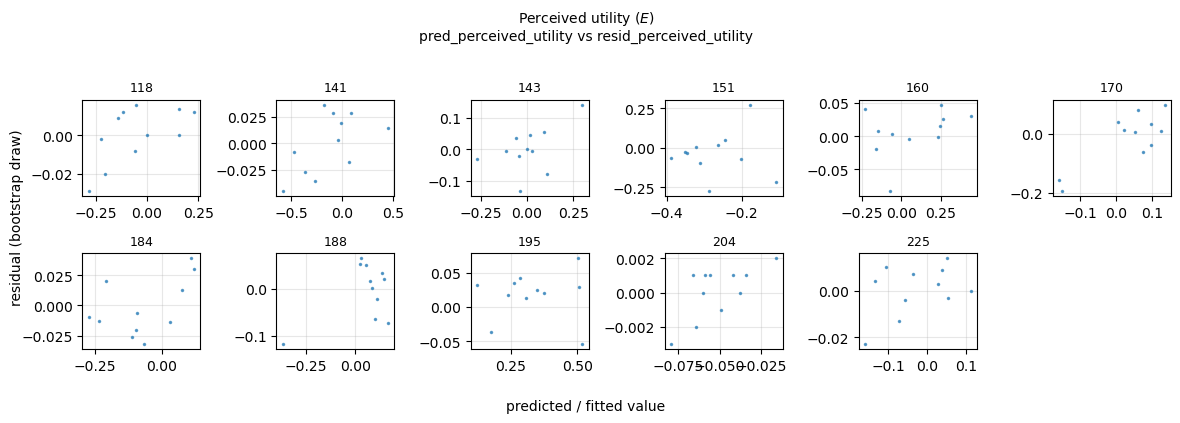

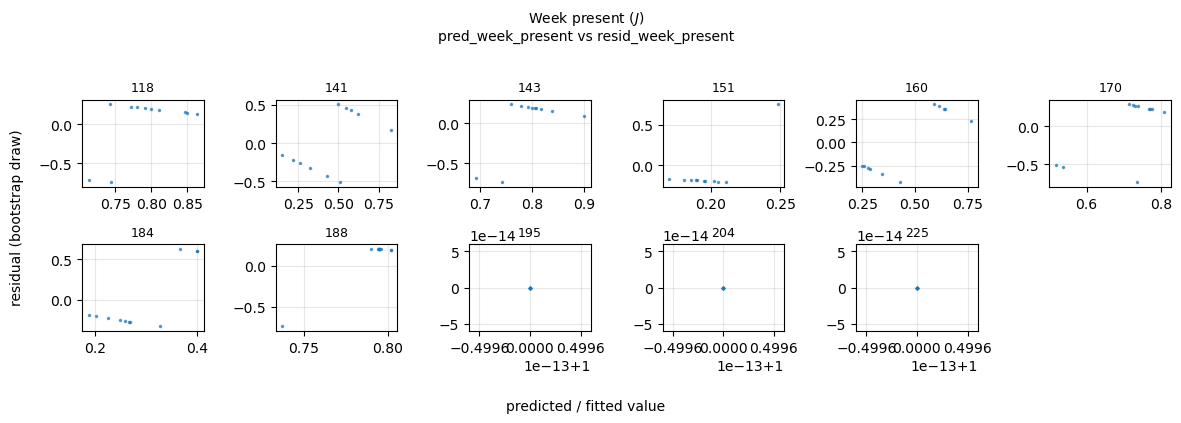

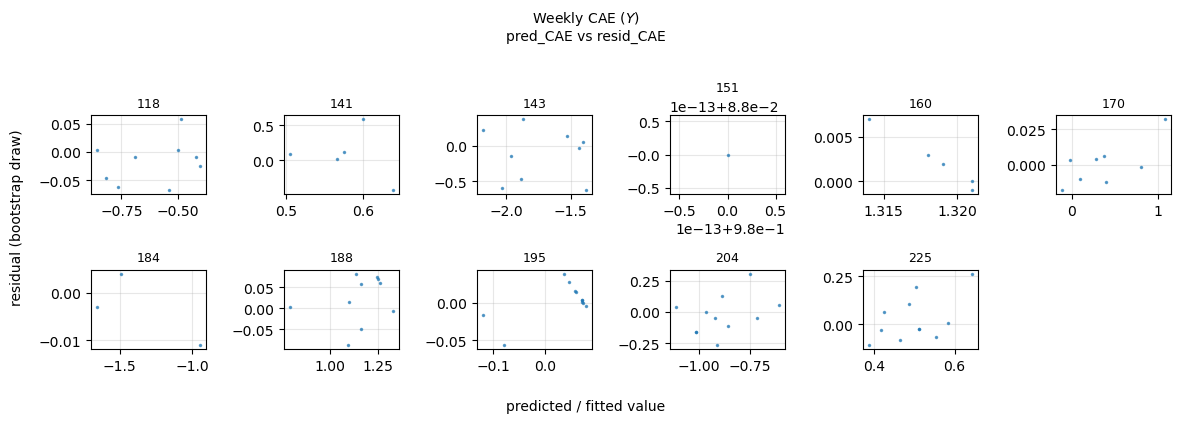

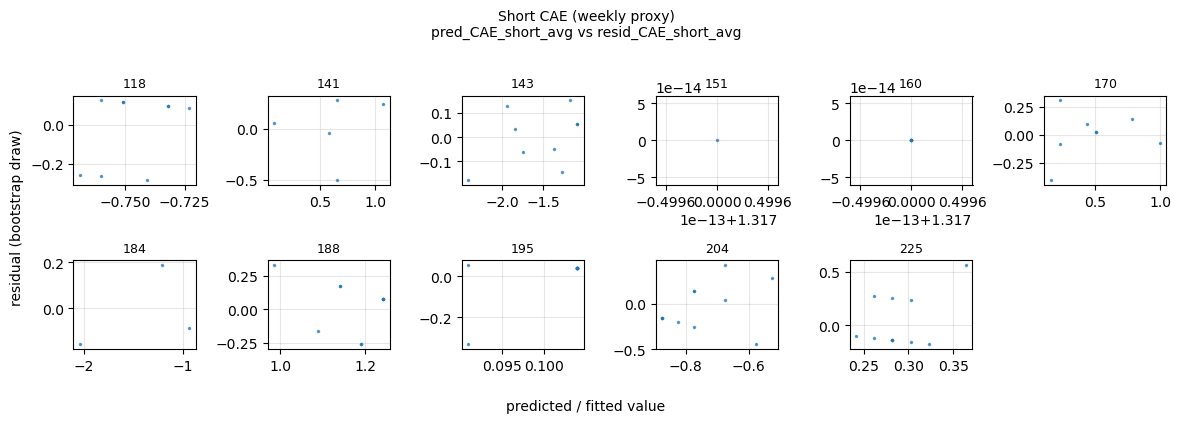

In [35]:
# Residual vs fitted (predicted) value for every ``resid_*`` in ``params_env_*.json``
# with matching ``pred_*`` in ``pred_*.json`` (same naming as ``2_fit_vanilla_testbed.py``).

RESID_PRED_PAIRS = [
    ("resid_prior2hour_step_count", "pred_prior2hour_step_count", r"Prior2h step count"),
    ("resid_recorded_physical_activity", "pred_recorded_physical_activity", r"Recorded PA (logit noise)"),
    ("resid_ws_interaction", "pred_ws_interaction", r"WS interaction (logit noise)"),
    ("resid_salience_interaction", "pred_salience_interaction", r"Salience interaction (logit noise)"),
    ("resid_fourSC", "pred_fourSC", r"fourSC / $M^Y$ slot"),
    ("resid_pageview", "pred_pageview", r"Pageview / $M^E$ slot"),
    ("resid_fitbitwearing", "pred_fitbitwearing", r"Fitbit wearing (daily)"),
    ("resid_dailysurvey", "pred_dailysurvey", r"Daily survey completion"),
    ("resid_antic", "pred_antic", r"Anticipated affect (daily)"),
    ("resid_perceived_utility", "pred_perceived_utility", r"Perceived utility ($E$)"),
    ("resid_week_present", "pred_week_present", r"Week present ($J$)"),
    ("resid_CAE", "pred_CAE", r"Weekly CAE ($Y$)"),
    ("resid_CAE_short_avg", "pred_CAE_short_avg", "Short CAE (weekly proxy)"),
]


def _plot_pred_vs_resid(resid_key: str, pred_key: str, title: str, *, alpha: float = 0.65):
    fig, axes, ncols = _resid_axes(len(userid_all))
    any_plotted = False
    for i, uid in enumerate(userid_all):
        pj = Path(file_pred_prefix + str(int(uid)) + ".json")
        ej = Path(file_params_env_prefix + str(int(uid)) + ".json")
        if not pj.is_file() or not ej.is_file():
            axes[i // ncols, i % ncols].set_visible(False)
            continue
        predicted = json.loads(pj.read_text(encoding="utf-8"))
        params = json.loads(ej.read_text(encoding="utf-8"))
        if pred_key not in predicted or resid_key not in params:
            axes[i // ncols, i % ncols].set_visible(False)
            continue
        pred = np.asarray(predicted[pred_key], dtype=float)
        resid = np.asarray(params[resid_key], dtype=float)
        pred, resid = _align_pred_resid(pred, resid)
        if pred.size == 0:
            ax = axes[i // ncols, i % ncols]
            ax.set_title(str(uid))
            ax.text(0.5, 0.5, "no finite pairs", ha="center", va="center", transform=ax.transAxes)
            continue
        any_plotted = True
        ax = axes[i // ncols, i % ncols]
        ax.grid(True, alpha=0.3)
        ax.plot(pred, resid, ".", alpha=alpha, markersize=3)
        ax.set_title(str(uid), fontsize=9)
        xpad = 0.06 * (np.nanmax(pred) - np.nanmin(pred) + 1e-12)
        ypad = 0.06 * (np.nanmax(resid) - np.nanmin(resid) + 1e-12)
        ax.set_xlim(np.nanmin(pred) - xpad, np.nanmax(pred) + xpad)
        ax.set_ylim(np.nanmin(resid) - ypad, np.nanmax(resid) + ypad)
    for k in range(len(userid_all), 2 * ncols):
        axes[k // ncols, k % ncols].set_visible(False)
    fig.suptitle(f"{title}\n{pred_key} vs {resid_key}", fontsize=10, y=1.02)
    fig.supxlabel("predicted / fitted value", fontsize=10)
    fig.supylabel("residual (bootstrap draw)", fontsize=10)
    fig.tight_layout()
    plt.show()
    if not any_plotted:
        print(f"(no panels for {resid_key} — missing keys or empty data)")


for rk, pk, ttl in RESID_PRED_PAIRS:
    _plot_pred_vs_resid(rk, pk, ttl)

